<h1> <a id="title"></a>Differencing and geostatistical error analysis in lidar topographic differencing: Workflow to download point cloud data</h1>

This work was funded by the [John Wesley Powell Center for Analysis and Synthesis (USGS G23AC00336)](https://www.usgs.gov/centers/john-wesley-powell-center-for-analysis-and-synthesis/science/a-national-topographic-change#overview) and [OpenTopography](https://opentopography.org).  OpenTopography is supported by the National Science Foundation under Awards # 2410799, 2410800 & 2410801.

<h2><a id="introduction"></a>1. Introduction</h2>

Vertical topographic differencing calculates net change in the vertical dimension by comparing digital elevation models (DEMs) collected at different times ([Izumida et al., 2017](https://doi.org/10.5194/nhess-17-1505-2017); [Wheaton et al., 2010](https://doi.org/10.1002/esp.1886)). Topographic differencing underpins a wide range of studies, spanning vegetation biomass changes, lava-flow emplacement ([Albino et al., 2015](https://doi.org/10.1002/2015JB011988)), fluvial and coastal floods ([Izumida et al., 2017](https://doi.org/10.5194/nhess-17-1505-2017)), landslides ([Lucieer et al., 2014](https://doi.org/10.1177/0309133313515293)), fine-scale fluvial sediment budgets ([Wheaton et al., 2010](https://doi.org/10.1002/esp.1886)), and tectonic activity ([Langridge et al., 2014](https://doi.org/10.1016/j.geomorph.2014.08.007); [Scott et al., 2018](https://doi.org/10.1029/2018JB015581)).

<h3><a id="differencing_def"></a>Vertical topographic differencing</h3>

Vertical differencing is the pixel-by-pixel subtraction of two digital-elevation models (DEMs) that share a common coordinate system and identical grid geometry (e.g., [Scott et al., 2021](https://doi.org/10.1130/GES02259.1)). Because every cell occupies the same planimetric position in both rasters, subtracting them yields a raster of elevation change ($\Delta z$). Researchers rarely inspect the differencing value of every cell individually. Instead, aggregate change is summarized over a specific feature or landform (net sediment deposition on a bar, net tree growth in a reforested stand, net inflation along a volcanic flank, etc.) The mean elevation change over a polygon $\Omega$ is:

$$\Delta z^{aggregate} = \frac{1}{N} \sum_{i=1}^{N} \Delta z_i$$

where the sum of $i$ individual topographic change measurements ($\Delta z_i$) is taken over the $N$ cells that fall inside $\Omega$.

<h3><a id="uncertainty_matters"></a>Why uncertainty matters</h3> 

The elevation change observed in a differenced raster can be decomposed as:

$$\Delta_{z}^{measured} = \Delta_{z}^{actual} + \Delta_{z}^{error}$$

where:
- **Δz<sub>actual</sub>** is the true vertical change (erosion, deposition, uplift, subsidence, construction, vegetation change, etc.)
- **Δz<sub>error</sub>** is the cumulative vertical error from data collection, processing, and alignment (GNSS/INS errors, boresight errors, DEM interpolation artifacts, alignment errors, metadata errors)

Errors present in either dataset are often of similar magnitude to the true change, particularly for legacy datasets acquired with less advanced instrumentation, lower point density, or incomplete metadata ([Glennie et al., 2014](https://doi.org/10.1002/2014GL059919)).


<h3><a id="error_types"></a>Error types in lidar topographic differencing</h3>

<h4><a id="short_scale"></a>Short-scale errors (meters to tens of meters)</h4>

| Error Type | Description | Key References |
|------------|-------------|----------------|
| **Random noise** | Sensor sensitivity, environmental conditions, and GNSS/IMU interference produce scattered positive/negative differences | [Glennie, 2007](https://doi.org/10.1515/jag.2007.017) |
| **Point misclassification** | Incorrect ground/vegetation/building classification creates meter-to-decameter artifacts with diffuse boundaries | [Passalacqua et al., 2015](https://doi.org/10.1016/j.earscirev.2015.05.012) |
| **Geometric distortion** | High laser incidence angles on steep slopes spread pulse energy, degrading measurement quality | [Schaer et al., 2007](https://doi.org/10.1117/12.717277) |


<h4><a id="mid_scale"></a>Mid-scale errors (hundred-meter scale)</h4> 

| Error Type | Description | Key References |
|------------|-------------|----------------|
| **Horizontal alignment errors** | Georeferencing offsets produce apparent vertical change correlated with topographic aspect; correctable via ICP registration | [Glennie et al., 2014](https://doi.org/10.1002/2014GL059919); [Besl & McKay, 1992](https://doi.org/10.1117/12.57955) |
| **Flight line striping** | Kinematic GNSS atmospheric delays create linear bands (hundreds of meters to kilometers wide) perpendicular to flight path | [Shan et al., 2007](https://doi.org/10.1201/9781420051438); [DeLong et al., 2022](https://doi.org/10.1029/2022EA002420) |

<h4><a id="long_scale"></a>Long-scale errors (kilometer scale)</h4>

| Error Type | Description | Key References |
|------------|-------------|----------------|
| **Instrument calibration biases** | Range calibration, uniform GNSS/IMU misalignment, or atmospheric corrections affect entire dataset uniformly | [Glennie, 2007](https://doi.org/10.1515/jag.2007.017); [Habib et al., 2009](https://doi.org/10.14358/PERS.75.10.1159) |
| **Geoid model errors** | Wrong geoid model produces 10–20 cm vertical shifts across the scene | Brigham et al. |
| **Ellipsoidal/orthometric confusion** | Mixing height systems causes vertical errors of tens of meters | Brigham et al. |


<h3><a id="workflow"></a>Our workflow</h3>

This notebook implements a geostatistical approach to quantify uncertainty in topographic differencing. The key insight is that **uncertainty is often structured, scale-dependent, and dominated by mid- and long-range correlation**.

**Notebook steps:**

1. [**Setup**](#setup): Install dependencies and configure the environment
2. [**Data Access & Download**](#data-access): Search the OpenTopography catalog, select compare/reference datasets, and download point clouds via PDAL streaming
3. [**Metadata Inspection & Update**](#load_metadata): Verify/correct CRS, vertical datum, geoid model, and epoch metadata
4. [**CRS Transformation**](#CRS_transformation): Align coordinate reference systems, vertical datums, and epochs
5. [**Point Cloud Alignment**](#alignment): ICP co-registration to correct horizontal offsets between surveys
6. [**2D DEM Differencing**](#differencing): Generate DEMs from point clouds and compute pixel-by-pixel elevation change
7. [**Visualization**](#visualization): Plot DEMs, hillshades, slopes, and the difference raster
8. [**Stable Area Identification**](#define-stable-areas): Delineate control zones where no real change is expected
9. [**Descriptive Statistics**](#descriptive-stats): Characterize the error distribution and check stationarity assumptions
10. [**Systematic Error Estimation**](#estimate-error): Estimate and remove vertical bias using the median of stable-area differences
11. [**Variography**](#Variography): Fit nested variogram models to capture multi-scale spatial error structure
12. [**Uncertainty Propagation**](#Total%20mean%20error): Propagate the error model to features of interest via Monte Carlo integration

<h2><a id="setup"></a>2. Setup</h2>

<h3><a id="colab"></a>Running the notebook in Colab</h3>

For ease-of-use, it is suggested to launch and execute these notebooks on <a href="https://colab.research.google.com/">Google Colaboratory</a> (Colab, for short), Google's Cloud Platform. Dependencies will be installed on a virtual machine on Google's cloud servers and the code will be executed directly in your browser. A major benefit of this is that you will have direct access to Google's high-end CPU/GPUs and will not have to install any dependencies locally. All deliverables will be saved to your personal Google Drive. To experiment and run one of the below Jupyter Notebooks on Google Colab click the "Open in Colab" badge below.


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Cassandra-Brigham/topographic-difference-uncertainty/blob/main/differencing_workflow_download_data.ipynb)

In [1]:
import os, sys, pathlib

# --- Colab guard ---
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    # 1) Mount Drive (idempotent)
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)

    # 2) Check if condacolab is already fully configured
    # We verify both that conda exists AND that LD_LIBRARY_PATH is set
    conda_ready = (
        os.path.exists("/usr/local/bin/conda") and
        "LD_LIBRARY_PATH" in os.environ
    )
    
    if conda_ready:
        import condacolab
        condacolab.check()
        print("✓ Condacolab already installed and configured")
    else:
        print("Installing condacolab (kernel will restart)...")
        !pip install -q condacolab
        import condacolab
        condacolab.install()  # This restarts the kernel
else:
    print("Not running in Colab; skipping condacolab setup.")

Not running in Colab; skipping condacolab setup.


**Kernel Restart Required**

If this is your first time running this notebook, the cell above will have installed `condacolab` and **automatically restarted the kernel**. This is expected behavior.

**Please proceed by running the cell below** to continue with the environment setup. The next cell will install PDAL and the remaining dependencies.

<h3><a id="folder"></a>Set your data path</h3>
Set the base directory that you want to work in.

- **Google Colab users**: Update `DATA_PATH` in the cell below to point to your data folder on Google Drive (e.g., `/content/drive/MyDrive/lidar-project`). Your Drive will be mounted when you run the setup cells.
- **Local users**: Update `DATA_PATH` in the cell below to point to your local data folder (e.g., `/Users/yourname/Documents/lidar-project`).

In [2]:
DATA_PATH = "your/path/here"

# Set base data directory based on environment
from pathlib import Path
if IN_COLAB:
    BASE_DATA_DIR = Path(DATA_PATH)
    
    print(f"Using Colab data directory: {BASE_DATA_DIR}")
else:
    BASE_DATA_DIR = Path(DATA_PATH)
    
    print(f"Using local data directory: {BASE_DATA_DIR}")

# Create base directory if it doesn't exist
BASE_DATA_DIR.mkdir(parents=True, exist_ok=True)

# Helper function to resolve data paths
def get_data_path(*path_parts):
    return str(BASE_DATA_DIR / Path(*path_parts))


# Folder where downloaded point clouds, intermediate files and final rasters will be saved
output_folder_name = "output"

OUTPUT_FOLDER = get_data_path(output_folder_name)

# If you have a shapefile to define your area of interest, set its path here
BOUNDS_SHAPEFILE_NAME = "bounds.shp"
BOUNDS_SHAPEFILE_PATH = get_data_path(BOUNDS_SHAPEFILE_NAME)


Using local data directory: your/path/here


In [3]:
import os, sys, pathlib
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    # Verify condacolab and install PDAL
    import condacolab
    condacolab.check()
    
    # Remove conflicting Python pin and install PDAL
    !rm -f /usr/local/conda-meta/pinned
    !mamba install -y -c conda-forge pdal python-pdal
    
    # Fix SQLite symlink - conda installs newer SQLite but old symlink remains
    # Dynamically find the installed SQLite version instead of hardcoding
    !sqlite_lib=$(ls /usr/local/lib/libsqlite3.so.3.* 2>/dev/null | head -1) && \
        if [ -n "$sqlite_lib" ]; then \
            sudo ln -sf "$sqlite_lib" /usr/local/lib/libsqlite3.so.0; \
            echo "Linked $sqlite_lib -> libsqlite3.so.0"; \
        fi
    
    # Fix numpy version conflict
    !{sys.executable} -m pip install -q "numpy<2.2"
    
    # Set PROJ environment
    os.environ['PROJ_LIB'] = '/usr/local/share/proj/'
    
    # Install topochange from GitHub
    print("\nInstalling topochange package...")
    !{sys.executable} -m pip install -q --no-cache-dir git+https://github.com/Cassandra-Brigham/topochange.git
    
    # Install additional packages not in topochange dependencies
    !{sys.executable} -m pip install -q small-gicp colormaps boto3
    
    # Verify PDAL via wrapper
    from topochange.pdal_wrapper import pdal, get_pdal_status
    status = get_pdal_status()
    print(f"\nEnvironment ready!")
    print(f"  PDAL version: {status['version']}")
    print(f"  PDAL mode: {status['mode']}")
else:
    print("Not running in Colab; skipping environment setup.")

Not running in Colab; skipping environment setup.


In [4]:
# Install visualization libraries
%pip install -q comm ipywidgets
%pip install -q ipyleaflet

# Fix pyproj PROJ path (Colab-specific, may need adjustment based on conda installation)
import os
import sys

# Set PROJ_LIB if needed (conda usually handles this automatically)
if IN_COLAB and not os.environ.get("PROJ_LIB"):
    from google.colab import output
    output.enable_custom_widget_manager()
    # Try common conda locations first
    possible_proj_paths = [
        "/opt/conda/share/proj",
        "/usr/share/proj", 
        "/usr/local/share/proj"
    ]
    for proj_path in possible_proj_paths:
        if os.path.isdir(proj_path):
            os.environ["PROJ_LIB"] = proj_path
            break

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


<h3><a id="api-key-setup"></a>API Key Setup</h3>

An [OpenTopography](https://opentopography.org) API key is required to search OpenTopography's catalog of datasets. Your alphanumeric API key is accessible at [MyOpenTopo](https://portal.opentopography.org/myopentopo) under "Get an API Key."

The code cell below tries to load your API key from multiple sources, in this order:
1. **Google Colab Secrets** (most secure for Colab users)
2. **Environment variable** (works locally and in Colab)
3. **Manual setting** (fallback)

Choose **one** of the methods below to store your key.

<h4><a id="colab-secrets"></a>Option 1: Google Colab Secrets (recommended for Colab users)</h4>

Google Colab provides a built-in "Secrets" feature that securely stores sensitive information like API keys. Your key won't be visible in the notebook or saved in the notebook's history.

1. Open your notebook in Google Colab.
2. Click the **key icon** (🔑) in the left sidebar to open the "Secrets" panel.
3. Click **"Add new secret"**.
4. In the "Name" field, enter: `OPENTOPOGRAPHY_API_KEY`
5. In the "Value" field, paste your API key.
6. Toggle the **"Notebook access"** switch to allow this notebook to access the secret.
7. Click the checkmark to save.

**Note:** Secrets are stored in your Google account and persist across sessions, so you only need to set this up once. However, you must enable "Notebook access" for each new notebook that needs the key.

<h4><a id="env-variable"></a>Option 2: Environment variable (recommended for local users)</h4>

Storing your API key in an environment variable prevents it from being hardcoded in source code, reducing the risk of exposure through sharing or version control.

**For Linux/macOS:**

Open a terminal and edit your shell profile script (`~/.zshrc` for Zsh, `~/.bashrc` for Bash):

```
nano ~/.zshrc
```

Add the following line at the end of the file (replace `your_api_key_here` with your actual key):

```
export OPENTOPOGRAPHY_API_KEY='your_api_key_here'
```

Save and exit (`Ctrl+X`, then `Y`, then `Enter` for nano). Reload the profile:

```
source ~/.zshrc
```

**For Windows:**

1. Search for "Environment Variables" in the Start menu.
2. Click on "Edit the system environment variables."
3. In the System Properties window, click on "Environment Variables."
4. Click "New" under User variables.
5. Set "Variable name" as `OPENTOPOGRAPHY_API_KEY` and "Variable value" as your API key.
6. Click OK and apply the changes.

<h4><a id="manual-key"></a>Option 3: Set the key manually in the notebook (fallback)</h4>

If you cannot use the methods above, you can set the key directly in the code cell below by uncommenting the manual assignment line. **Be cautious about sharing the notebook if your API key is visible.**

```python
os.environ['OPENTOPOGRAPHY_API_KEY'] = 'your_api_key_here'
```

In [5]:
api_key = None

if IN_COLAB:
    # Try Colab secrets first (recommended for Colab users)
    try:
        from google.colab import userdata
        api_key = userdata.get('OPENTOPOGRAPHY_API_KEY')
        print("✓ Using OPENTOPOGRAPHY_API_KEY from Colab secrets")
    except Exception:
        # Fall back to environment variable
        api_key = os.getenv('OPENTOPOGRAPHY_API_KEY')
        if api_key:
            print("✓ Using OPENTOPOGRAPHY_API_KEY from environment variable")
        else:
            print("⚠️  OPENTOPOGRAPHY_API_KEY not found!")
            print("   Option 1 (Recommended): Add to Colab secrets via the 🔑 icon in left sidebar")
            print("   Option 2: Run this in a cell: os.environ['OPENTOPO_API_KEY'] = 'your_key_here'")
            print("   Get your key at: https://portal.opentopography.org/requestService")
else:
    # Local environment - use environment variable
    api_key = os.getenv('OPENTOPOGRAPHY_API_KEY')
    if api_key:
        print("✓ Using OPENTOPOGRAPHY_API_KEY from environment variable")
    else:
        print("⚠️  OPENTOPOGRAPHY_API_KEY not found in environment variables")
        print("   Set it in your shell before running Jupyter, or run:")
        print("   os.environ['OPENTOPOGRAPHY_API_KEY'] = 'your_key_here'")
# Set the environment variable if we found a key
if api_key:
    os.environ['OPENTOPOGRAPHY_API_KEY'] = api_key

✓ Using OPENTOPOGRAPHY_API_KEY from environment variable


<h3><a id="import-libraries"></a>Import required libraries</h3>

This cell imports the necessary Python libraries for data handling and analysis, including custom functions from the provided scripts for differencing, variography, and stable area analysis.

In [6]:
import os
import numpy as np
import rasterio
from scipy.spatial.transform import Rotation

# Core classes
from topochange import (
    Raster,
    PointCloud,
    PointCloudPair,
    VariogramAnalysis,
    RasterDataHandler,
    StatisticalAnalysis,
    RegionalUncertaintyEstimator,
)

# Interactive features (requires ipyleaflet)
from topochange import (
    TopoMapInteractor,
    StableAreaRasterizer,
    StableAreaAnalyzer,
)

# Geoid utilities
from topochange.geoid_utils import (
    ensure_proj_grids_for_region,
    get_all_proj_data_dirs,
)

# Alignment
from topochange.alignment import LandscapeAligner, RegistrationConfig

# Data access
from topochange.data_access import (
        DataAccess,
        OpenTopographyQuery,
        GetDEMs,
    )


SEED = 42

if IN_COLAB:
    print("Setting up PROJ geoid grids for Colab...")
    print(f"PROJ data directories: {get_all_proj_data_dirs()}")
    
    # Ensure common US NOAA geoid grids are available
    ensure_proj_grids_for_region('us_noaa', verbose=True)
    
    print("\nPROJ geoid grids ready")

<h2><a id="data-access"></a>3. Data access, download and pre-processing</h2>

This section outlines how to define an area of interest (AOI), search the OpenTopography data catalog for available datasets, and download your desired compare (older) and reference (newer) topographic datasets. 

The pre-processing steps ensure that both datasets are aligned to a common coordinate reference system (CRS), grid, and vertical datum, which is essential for accurate differencing

<h3><a id="Load-API-Key"></a>Load API key</h3>

In [7]:
# After setting the environment variable, access your API key in this notebook.
API_Key = os.getenv("OPENTOPOGRAPHY_API_KEY")

# If your API key is not set correctly, you can set it manually here. Be careful about sharing the notebook if your API key is visible.
#API_Key = "your_api_key_here"

if API_Key is not None:
    print("API Key loaded successfully!")
else:
    print("Failed to load API Key.")

API Key loaded successfully!


<h3><a id="Define-AOI"></a>Define area of interest</h3>

To specify the geographic region for your dataset search, you have three options. You can 1) draw a bounding box directly on the interactive map embedded in this notebook: simply click and drag to sketch the rectangle around your target area, and the notebook captures both the corner coordinates and the equivalent WKT polygon for your API queries; 2) manually enter latitude and longitude bounds if you know the exact coordinates of your area of interest; or 3) upload a shapefile or GEOJSON to automatically populate the bounds.

<h4><a id="Option-1-Draw-Map"></a>Option 1: Draw a bounding box on an interactive map</h4>

In [8]:
da = DataAccess()
da.init_ot_catalog_map(zoom=3)

Map(center=[39.8283, -98.5795], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'z…

In [9]:
# Verify bounds
da.bounds

{'south': 39.773714,
 'west': -98.614354,
 'north': 39.776518,
 'east': -98.610663,
 'polygon_wkt': ['-98.614354, 39.773714, -98.614354, 39.776518, -98.610663, 39.776518, -98.610663, 39.773714, -98.614354, 39.773714']}

<h4><a id="Option-2-Manual-Bounds"></a> Option 2: Define bounds manually</h4>

Set the boundary coordinates for your AOI in EPSG:4326.

In [ ]:
da = DataAccess()
south = 38.953619
north = 38.953827
west =  -104.926257
east = -104.925967
da.define_bounds_manual(south, north, west, east)

In [ ]:
# Verify bounds
da.bounds

<h4><a id="Option-3-Upload-File"></a> Option 3: Define bounds using an uploaded file</h4>

In [ ]:
da = DataAccess()
da.define_bounds_from_file(BOUNDS_SHAPEFILE_PATH, target_crs='EPSG:4326')

In [ ]:
# Verify bounds
da.bounds

<h3><a id="Use-OT-Catalog-comp-ref"></a> Use OT Catalog To Find Paired Compare/Reference Datasets</h3>

This section uses OpenTopography’s `otCatalog` API endpoint to perform a bounding‐box search of available datasets within the area of interest defined above. 

In [10]:
# Initialize the OpenTopography query object with our DataAccess instance
otq = OpenTopographyQuery(da)

otq.query_catalog(
    product_format="PointCloud",            # only return point cloud products; can use "Raster" to view raster products or omit to get all
    include_federated=True,                 # include external catalogs (e.g. USGS 3DEP) via OpenTopography
    detail=False,                           # set to True for full metadata; False returns summary fields
    save_as=get_data_path("results.json")   # save raw JSON response to this file for inspection or reuse
)

# Show the first few rows of the catalog dataframe
otq.catalog_df

,Name,Short Name,ID type,Data Source,Property ID,Horizontal EPSG,Vertical Coordinates,Clean Name,StartDate,EndDate
0,USGS LPC KS Area2 B1 2012 LAS 2016,None,USGS_3DEP_ID,usgs,USGS_LPC_KS_Area2_B1_2012_LAS_2016,3857,NAVD88 height,USGS_LPC_KS_Area2_B1_2012_LAS_2016,2012-01-07,2012-01-10
1,KS Statewide B10 2018,None,USGS_3DEP_ID,usgs,KS_Statewide_B10_2018,3857,NAVD88 height - Geoid12B (Meters),KS_Statewide_B10_2018,2018-04-30,2019-03-20


<h4><a id="Select-Compare-Ref"></a> Select compare/reference datasets for differencing</h4>
Using the indices of the entries listed above, set the index of the desired compare dataset and that of the desired reference index.

In [11]:
# choose the indices of the desired reference and compare datasets 
compare_index   = 0   # Older/pre-event dataset
reference_index = 1   # Younger/post-event dataset

# now tell the query object which ones to use as which
otq.pick(compare_index, reference_index)

⚠️  Vertical CRSs differ between datasets
⚠️  Compare vertical CRS: 'NAVD88 height' - geoid not detected, use set_compare_geoid()
🔹 Reference Geoid: geoid12b
🔹 Compare Units: metre
🔹 Reference Units: metre
🔹 Compare Epoch: 2012-01-08 (2012.0191)
🔹 Reference Epoch: 2018-10-09 (2018.7699)


(Name                    USGS LPC KS Area2 B1 2012 LAS 2016
 Short Name                                            None
 ID type                                       USGS_3DEP_ID
 Data Source                                           usgs
 Property ID             USGS_LPC_KS_Area2_B1_2012_LAS_2016
 Horizontal EPSG                                       3857
 Vertical Coordinates                         NAVD88 height
 Clean Name              USGS_LPC_KS_Area2_B1_2012_LAS_2016
 StartDate                                       2012-01-07
 EndDate                                         2012-01-10
 Name: 0, dtype: object,
 Name                                KS Statewide B10 2018
 Short Name                                           None
 ID type                                      USGS_3DEP_ID
 Data Source                                          usgs
 Property ID                         KS_Statewide_B10_2018
 Horizontal EPSG                                      3857
 Vertical Coordinates

<h5><a id="check_meta"></a> Check the metadata of the compare and reference datasets</h5>
If the metadata is incorrect, you can set it manually later in the notebook. Make note of the metadata inconsistencies and try to determine the correct metadata. This information can be found in several places:

- **OpenTopography data pages**: Each dataset has a metadata page with survey details including CRS, datum, survey date, and geoid information. Look under the "Overview" or "Coordinates and Classification" sections. The "Full Metadata" link in the "Overview" section will take you to the original data index file.
- **Survey reports**: Most lidar acquisitions include a project report (often a PDF) documenting collection parameters, coordinate systems, and vertical datums.
- **USGS metadata**: For USGS 3DEP and other national elevation data, metadata is available at the [USGS National Geospatial Technical Operations Center](https://thor-f5.er.usgs.gov/ngtoc/metadata/waf/elevation/)
- **NOAA Digital Coast**: For coastal lidar data, metadata can be found in the [NOAA Digital Coast portal](https://coast.noaa.gov/digitalcoast/) or the individual dataset index files, e.g., [NOAA NOS Coastal Lidar index](https://noaa-nos-coastal-lidar-pds.s3.amazonaws.com/laz/geoid18/8866/index.html)
- **State/agency GIS portals**: Many state/international agencies maintain their own lidar portals with detailed metadata documentation.



In [12]:
compare_meta = otq.get_metadata_dict("compare")
compare_meta

{'epoch': 2012.01912568306,
 'epoch_date': datetime.date(2012, 1, 8),
 'geoid_model': None,
 'is_orthometric': True,
 'horizontal_crs': '3857',
 'vertical_datum': 'NAVD88',
 'vertical_units': 'meter',
 'vertical_unit_info': UnitInfo('meter', factor=1.0),
 'vertical_crs_string': 'NAVD88 height',
 'name': 'USGS LPC KS Area2 B1 2012 LAS 2016',
 'short_name': None,
 'data_source': 'usgs',
 'property_id': 'USGS_LPC_KS_Area2_B1_2012_LAS_2016'}

In [13]:
reference_meta = otq.get_metadata_dict("reference")
reference_meta

{'epoch': 2018.7698630136986,
 'epoch_date': datetime.date(2018, 10, 9),
 'geoid_model': 'geoid12b',
 'is_orthometric': True,
 'horizontal_crs': '3857',
 'vertical_datum': 'NAVD88',
 'vertical_units': 'meter',
 'vertical_unit_info': UnitInfo('meter', factor=1.0),
 'vertical_crs_string': 'NAVD88 height - Geoid12B (Meters)',
 'name': 'KS Statewide B10 2018',
 'short_name': None,
 'data_source': 'usgs',
 'property_id': 'KS_Statewide_B10_2018'}

Two metadata types that are often missing from the catalog entry are the vertical units and the geoid model (if the coordinates are orthometric). Set their values here to be safe.

In [14]:
VERTICAL_UNITS = "meter"  # or "foot", "us_survey_foot", etc. based on your datasets
GEOID_MODEL = "geoid12b"  # or "geoid18", "geoid03", etc. based on your datasets

<h3><a id="get_pcs"></a> Download point clouds </h3>

This section downloads one merged point cloud per dataset (compare and reference) using PDAL streaming pipelines. The point clouds are saved as compressed LAZ files for subsequent processing (CRS transformation, alignment, DEM creation, and differencing).

- **OpenTopography datasets**: Tiles are downloaded from S3 in parallel and merged into a single LAZ via a PDAL streaming pipeline (`filters.merge` + `writers.las`).
- **USGS/NOAA EPT datasets**: PDAL's `readers.ept` streams data directly from the cloud EPT endpoint and writes a single LAZ—no intermediate tile files are created.

In [15]:
# Initialize the download object with our DataAccess and OpenTopographyQuery instances
gdems = GetDEMs(da, otq)

# Folder where downloaded point clouds and intermediate files will be saved
folder = get_data_path("output/")
os.makedirs(folder, exist_ok=True)

# Base name for output files
output_name = "ot_differencing"

# Download compare point cloud (streams tiles and merges into single LAZ)
compare_pc_path = gdems.pointcloud_download_workflow(
    folder,
    output_name,
    API_Key,
    dataset_type="compare",
    epoch=otq.compare_epoch,
    filterNoise=True,
    reclassify=False,
    pc_resolution=0.1,
    outCRS="WGS84 UTM",
)
print(f"Compare point cloud saved: {compare_pc_path}")

# Download reference point cloud
reference_pc_path = gdems.pointcloud_download_workflow(
    folder,
    output_name,
    API_Key,
    dataset_type="reference",
    epoch=otq.reference_epoch,
    filterNoise=True,
    reclassify=False,
    pc_resolution=0.1,
    outCRS="WGS84 UTM",
)
print(f"Reference point cloud saved: {reference_pc_path}")

/opt/anaconda3/envs/crs_transformation/lib/python3.13/site-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)


Using epoch 2012-01-08 for compare dataset via PROJ string.


INFO:topochange.data_access:Point cloud saved: your/path/here/output/ot_differencing_compare.laz


Compare point cloud saved: your/path/here/output/ot_differencing_compare.laz
Using epoch 2018-10-09 for reference dataset via PROJ string.


INFO:topochange.data_access:Point cloud saved: your/path/here/output/ot_differencing_reference.laz


Reference point cloud saved: your/path/here/output/ot_differencing_reference.laz


<h3><a id="load_metadata"></a> Load and inspect point cloud metadata </h3>

Create `PointCloud` objects from the downloaded LAZ files and inspect their metadata. Key fields to check include the compound CRS, horizontal and vertical CRS, geoid model, epoch, and vertical units. If any metadata is missing or incorrect, you can update it in the cells below.

In [16]:
# Create PointCloud objects and extract metadata
pc1 = PointCloud(compare_pc_path)
pc1.from_file()
pc1.print_metadata()


--- CRS Information ---
Property                  Value                                             
---------------------------------------------------------------------------
Compound CRS              PROJCS["unknown",GEOGCS["unknown",DATUM["WGS_198
Horizontal CRS            PROJCS["unknown",GEOGCS["unknown",DATUM["WGS_198
Vertical CRS              
Geoid model               None

--- Point Cloud Metadata ---
Property                  Value                                             
---------------------------------------------------------------------------
Total points              55,376
Bounds                    (533025.91, 4402713.34, 533343.06, 4403025.84)
Horizontal units          metre (m) (EPSG:9001)
Vertical units            unknown (?)

--- Time Information ---
Property                  Value                                             
---------------------------------------------------------------------------
Creation year             2026
Creation DOY              36


In [17]:
pc2 = PointCloud(reference_pc_path)
pc2.from_file()
pc2.print_metadata()


--- CRS Information ---
Property                  Value                                             
---------------------------------------------------------------------------
Compound CRS              PROJCS["unknown",GEOGCS["unknown",DATUM["WGS_198
Horizontal CRS            PROJCS["unknown",GEOGCS["unknown",DATUM["WGS_198
Vertical CRS              
Geoid model               None

--- Point Cloud Metadata ---
Property                  Value                                             
---------------------------------------------------------------------------
Total points              293,475
Bounds                    (533025.78, 4402713.34, 533343.14, 4403025.83)
Horizontal units          metre (m) (EPSG:9001)
Vertical units            unknown (?)

--- Time Information ---
Property                  Value                                             
---------------------------------------------------------------------------
Creation year             2026
Creation DOY              36

<h3><a id="update_metadata"></a> Update point cloud metadata </h3>

Sometimes the point cloud file will lack important metadata or the metadata will be parsed incorrectly. Use the catalog metadata to auto-populate what we can, then set any remaining fields manually.

The metadata can be verified against:
- **OpenTopography data pages**: CRS, datum, survey date, geoid info under "Overview" or "Coordinates and Classification"
- **Survey reports**: PDF project reports documenting collection parameters
- **USGS metadata**: [NGTOC metadata](https://thor-f5.er.usgs.gov/ngtoc/metadata/waf/elevation/)
- **NOAA Digital Coast**: [NOAA Digital Coast portal](https://coast.noaa.gov/digitalcoast/)

In [18]:
# Auto-populate metadata from the OpenTopography catalog where possible
compare_meta = otq.get_metadata_dict("compare")
reference_meta = otq.get_metadata_dict("reference")

# --- Compare point cloud metadata ---
# Set geoid model (often missing from catalog)
if GEOID_MODEL:
    from topochange.geoid_utils import select_geoid_grid
    geoid_grid, _ = select_geoid_grid(GEOID_MODEL, verbose=True)
    pc1.add_metadata(geoid_model=geoid_grid)

# Set epoch from catalog
if otq.compare_epoch:
    pc1.add_metadata(epoch=str(otq.compare_epoch))

# Set vertical CRS if known
compare_vert_crs = compare_meta.get("vertical_crs")
if compare_vert_crs:
    pc1.add_metadata(vertical_CRS=str(compare_vert_crs))

print("Compare PC metadata after update:")
print(f"  Compound CRS: {pc1.current_compound_crs}")
print(f"  Horizontal CRS: {pc1.current_horizontal_crs}")
print(f"  Vertical CRS: {pc1.current_vertical_crs}")
print(f"  Geoid model: {pc1.geoid_model}")
print(f"  Epoch: {pc1.epoch}")
print(f"  Is orthometric: {pc1.is_orthometric}")

Geoid grids for 'geoid12b' (canonical 'geoid12b'):
  [0] us_noaa_g2012bu0.tif (local)  <== selected (auto-selected local u0/CONUS grid)
  [1] us_noaa_g2012bu0_lonfix.tif (local)
  [2] us_noaa_g2012ba0.tif (local)
  [3] us_noaa_g2012bg0.tif (local)
  [4] us_noaa_g2012bh0.tif (local)
  [5] us_noaa_g2012bp0.tif (local)
  [6] us_noaa_g2012bs0.tif (local)
  [7] us_noaa_g2012bu0.tif (local)
Compare PC metadata after update:
  Compound CRS: PROJCRS["unknown",BASEGEOGCRS["unknown",DATUM["World Geodetic System 1984",ELLIPSOID["WGS 84",6378137,298.257223563,LENGTHUNIT["metre",1]],ID["EPSG",6326]],PRIMEM["Greenwich",0,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8901]]],CONVERSION["UTM zone 14N",METHOD["Transverse Mercator",ID["EPSG",9807]],PARAMETER["Latitude of natural origin",0,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8801]],PARAMETER["Longitude of natural origin",-99,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8802]],PARAMETER["Scale factor at natural origin",0.9996,SCALEUNIT

In [19]:
# --- Reference point cloud metadata ---
if GEOID_MODEL:
    geoid_grid_ref, _ = select_geoid_grid(GEOID_MODEL, verbose=True)
    pc2.add_metadata(geoid_model=geoid_grid_ref)

if otq.reference_epoch:
    pc2.add_metadata(epoch=str(otq.reference_epoch))

reference_vert_crs = reference_meta.get("vertical_crs")
if reference_vert_crs:
    pc2.add_metadata(vertical_CRS=str(reference_vert_crs))

print("Reference PC metadata after update:")
print(f"  Compound CRS: {pc2.current_compound_crs}")
print(f"  Horizontal CRS: {pc2.current_horizontal_crs}")
print(f"  Vertical CRS: {pc2.current_vertical_crs}")
print(f"  Geoid model: {pc2.geoid_model}")
print(f"  Epoch: {pc2.epoch}")
print(f"  Is orthometric: {pc2.is_orthometric}")

Geoid grids for 'geoid12b' (canonical 'geoid12b'):
  [0] us_noaa_g2012bu0.tif (local)  <== selected (auto-selected local u0/CONUS grid)
  [1] us_noaa_g2012bu0_lonfix.tif (local)
  [2] us_noaa_g2012ba0.tif (local)
  [3] us_noaa_g2012bg0.tif (local)
  [4] us_noaa_g2012bh0.tif (local)
  [5] us_noaa_g2012bp0.tif (local)
  [6] us_noaa_g2012bs0.tif (local)
  [7] us_noaa_g2012bu0.tif (local)
Reference PC metadata after update:
  Compound CRS: PROJCRS["unknown",BASEGEOGCRS["unknown",DATUM["World Geodetic System 1984",ELLIPSOID["WGS 84",6378137,298.257223563,LENGTHUNIT["metre",1]],ID["EPSG",6326]],PRIMEM["Greenwich",0,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8901]]],CONVERSION["UTM zone 14N",METHOD["Transverse Mercator",ID["EPSG",9807]],PARAMETER["Latitude of natural origin",0,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8801]],PARAMETER["Longitude of natural origin",-99,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8802]],PARAMETER["Scale factor at natural origin",0.9996,SCALEUN

<h3><a id="CRS_transformation"></a> CRS transformation and overlap </h3>

Before differencing, both datasets must share a common reference frame: horizontal CRS, vertical datum, geoid model, and coordinate epoch. The `PointCloudPair` handles these transformations in a single composable PDAL pipeline.

After transformation, both clouds are cropped to their overlap area with an interior buffer on the compare cloud to avoid edge effects.

In [20]:
# Create PointCloudPair and check what transformations are needed
pc_pair = PointCloudPair(pc1, pc2)
pc_pair.print_comparison()


--- PointCloudPair Comparison ---

Compare (pc1):   ot_differencing_compare.laz
Reference (pc2): ot_differencing_reference.laz

Parameter            Match    PC1                  PC2                 
----------------------------------------------------------------------
Horizontal CRS       Yes      EPSG:32614           EPSG:32614          
Vertical CRS         Yes      Unknown              Unknown             
Geoid Model          Yes      us_noaa_g2012bu0.tif us_noaa_g2012bu0.tif
Epoch                No       2012.0191            2018.7699           
Vertical Units       Yes      unknown              unknown             
----------------------------------------------------------------------

Transformations needed: epoch



In [21]:
# Transform compare point cloud CRS to match reference
transformed = pc_pair.transform_compare_to_match_reference(
    skip_epoch=True,  # Set to False for full epoch alignment
    verbose=True,
)

# Compute overlap area
overlap_result = pc_pair.compute_overlap_polygon(use_transformed=True)
print(f"\nOverlap area: {overlap_result['overlap_area']:,.0f} m²")
print(f"PC1 overlap: {overlap_result['overlap_fraction_pc1']*100:.1f}%")
print(f"PC2 overlap: {overlap_result['overlap_fraction_pc2']*100:.1f}%")

# Crop both clouds to overlap area
pc1_cropped, pc2_cropped = pc_pair.crop_to_overlap(
    interior_buffer=10.0,
    verbose=True,
    overwrite=True,
)
print(f"\nPC1 cropped: {pc1_cropped.total_points:,} points")
print(f"PC2 cropped: {pc2_cropped.total_points:,} points")


--- Transform compare to match reference ---
Transformations needed: ['epoch']
No transformations needed.

Output: your/path/here/output/ot_differencing_compare.laz

--- Computing true data footprint for reference cloud ---
True extent computed successfully
True extent bounds (utm): (533024.0848969385, 4402704.199999999, 533341.5700000003, 4403024.0)
True extent area (utm): 99,475 m²
PC2 header bounds: (533025.78, 4402713.34) to (533343.14, 4403025.83)

--- Cropping to Overlap Area ---
PC1 poly_4326 bounds: (-98.61458606758812, 39.7735602483236, -98.61055013986395, 39.77661206189489)
PC2 poly_4326 bounds: (-98.61455583831554, 39.77348898109576, -98.61051120501591, 39.77662210672498)
Common CRS: 32614
PC1 native CRS: PROJCRS["unknown",BASEGEOGCRS["unknown",DATUM["World Geodetic System 1984",ELLIP...
PC2 native CRS: PROJCRS["unknown",BASEGEOGCRS["unknown",DATUM["World Geodetic System 1984",ELLIP...
PC1 area (bounding box): 110,281 m²
PC2 area (bounding box): 117,863 m²
PC2 area (true ex


Overlap area: 109,816 m²
PC1 overlap: 99.6%
PC2 overlap: 93.2%


Cropping pc2 to: ot_differencing_reference_intersection.laz



PC1 cropped: 49,276 points
PC2 cropped: 293,475 points


Cropping complete.


<h3><a id="alignment"></a> Point cloud alignment </h3>

Co-register the two point clouds using ICP to correct residual horizontal offsets. Even small offsets produce apparent vertical changes correlated with topographic aspect. The `LandscapeAligner` uses ground-classified points for robust registration.

| Method | Description | Best for |
|--------|-------------|----------|
| `icp` | Classic point-to-point ICP | Simple, fast alignment |
| `plane_icp` | Point-to-plane ICP | Smoother surfaces |
| `gicp` | Generalized ICP with covariance | Robust to noise, preferred locally |
| `vgicp` | Voxelized GICP (GPU-accelerated) | Large point clouds, preferred for Colab |

In [22]:
if IN_COLAB:
    config = RegistrationConfig(
        point_filter="ground",
        max_correspondence_distance=1.0,
        crop_dimensions=(200, 200),
        method="vgicp",
    )
else:
    config = RegistrationConfig(
        point_filter="ground",
        max_correspondence_distance=1.0,
        method="gicp",
    )

aligner = LandscapeAligner(config)
result = aligner.align(source=pc1_cropped, target=pc2_cropped)

INFO:topochange.alignment:Starting registration: ot_differencing_compare_intersection_buffered -> ot_differencing_reference_intersection
INFO:topochange.alignment:Filtered source to classifications: [2]
INFO:topochange.alignment:Removed outliers from source
INFO:topochange.alignment:Filtered target to classifications: [2]
INFO:topochange.alignment:Removed outliers from target
INFO:topochange.alignment:After preprocessing: 35752 source, 212509 target points
INFO:topochange.alignment:Centering to origin (centroid: [533181.6, 4402871.0, 520.6])
INFO:topochange.alignment:Coarse alignment completed
INFO:topochange.alignment:Running gicp registration...
INFO:topochange.alignment:Preprocessing (covariance estimation, no downsampling)...
INFO:topochange.alignment:After preprocessing: 35752 source, 205898 target points
INFO:topochange.alignment:Registration succeeded on attempt 1


In [23]:
print(f"RMSE: {result.rmse:.4f} m")
print(f"Fitness: {result.fitness:.2%}")
print(f"Converged: {result.converged}")
print(f"Iterations: {result.iterations}")
print(f"Method: {result.method_used}")
print(f"\nTransformation matrix:\n{result.transformation}")
print(f"\nCentroid used: {result.centroid}")

# Extract rotation and translation from 4x4 transformation
rotation = result.transformation[:3, :3]
translation = result.transformation[:3, 3]

print(f"\nTranslation (x, y, z): {translation}")

r = Rotation.from_matrix(rotation)
euler_angles = r.as_euler('xyz', degrees=True)
print(f"Rotation (roll, pitch, yaw) in degrees: {euler_angles}")

RMSE: 0.3266 m
Fitness: 99.74%
Converged: True
Iterations: 8
Method: gicp

Transformation matrix:
[[ 9.99999962e-01  2.69660526e-04 -5.81030056e-05 -2.62420214e-01]
 [-2.69663387e-04  9.99999962e-01 -4.92468595e-05  2.16504421e-01]
 [ 5.80897234e-05  4.92625258e-05  9.99999997e-01  2.59002363e+01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]

Centroid used: [5.33181637e+05 4.40287097e+06 5.20647889e+02]

Translation (x, y, z): [-0.26242021  0.21650442 25.90023631]
Rotation (roll, pitch, yaw) in degrees: [ 0.00282253 -0.0033283  -0.01545057]


<h3><a id="differencing"></a> 2D DEM differencing </h3>

Generate DEMs from the point clouds and compute pixel-by-pixel elevation change. Three scenarios are computed to illustrate the effect of each processing step:

| Scenario | DEM Sources | What it tests |
|----------|-------------|---------------|
| **Horizontal-only** | Raw DSMs (same horizontal CRS, no vertical transform) | Baseline |
| **Transformed** | After full CRS transformation (horizontal + vertical + epoch) | Effect of CRS alignment |
| **Aligned** | After transformation + ICP co-registration | Best-case with geometric correction |


Computing 2D (DEM-based) Difference

--- No horizontal transform needed, using original pc1 ---
DEM1 source: dsm (ot_differencing_compare.laz)
DEM2 source: dsm (ot_differencing_reference_intersection.laz)
DEM1 type: DSM
DEM2 type: DSM

Creating DEM from pc1: ot_differencing_compare.laz
/opt/anaconda3/envs/crs_transformation/lib/python3.13/site-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)
Creating DEM from pc2: ot_differencing_reference_intersection.laz

DEM1: your/path/here/output/ot_differencing_compare_dsm_1m.tif
DEM2: your/path/here/output/ot_differencing_reference_intersection_dsm_1m.tif

RasterPair comparison:

--- Computing Difference (raster2 - raster1) ---

--- Raster Transformation ---
Step                           Status     


--- RasterPair Summary ---

Property           Raster1              Raster2             
----------------------------------------------------------
File               ot_differencing_co   ot_differencing_re  
Epoch              2012.01912568306     2018.7698630136986  
Geoid              us_noaa_g2012bu0.t   us_noaa_g2012bu0.t  
Vertical Units     unknown              unknown             

Parameter            Match   
----------------------------
Horizontal CRS       Yes     
Vertical CRS         Yes     
Geoid                Yes     
Epoch                No      
Units                Yes     
Grid                 No      

Transformations needed: epoch, grid




DEM1: your/path/here/output/ot_differencing_compare_dsm_1m.tif
DEM2: your/path/here/output/ot_differencing_reference_intersection_dsm_1m.tif

RasterPair comparison:

--- Computing Difference (raster2 - raster1) ---

--- Raster Transformation ---
Step                           Status                        
------------------------------------------------------------
Grid alignment                 [done]
/opt/anaconda3/envs/crs_transformation/lib/python3.13/site-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)
------------------------------------------------------------

Source       Valid Pixels         Percent   
------------------------------------------
Raster1            98,745 / 99,534   99.2%
Raster2            99,391 / 99,534   99.9%


--- RasterPair Summary ---

Property           Raster1              Raster2             
----------------------------------------------------------
File               ot_differencing_co   ot_differencing_re  
Epoch              2012.01912568306     2018.7698630136986  
Geoid              us_noaa_g2012bu0.t   us_noaa_g2012bu0.t  
Vertical Units     unknown              unknown             

Parameter            Match   
----------------------------
Horizontal CRS       Yes     
Vertical CRS         Yes     
Geoid                Yes     
Epoch                No      
Units                Yes     
Grid                 No      

Transformations needed: epoch, grid



  After preprocessing: 35493 source, 101675 target points

Alignment Results:
  Converged: True
  Fitness (inlier ratio): 0.0000
  RMSE: inf m
  Inlier correspondences: 0
  Translation: [0.0000, 0.0000, 0.0000] m
  Rotation: 0.0000°

Applying transformation to: your/path/here/output/ot_differencing_compare_transformed_intersection_buffered_aligned_transformed.laz
INFO:topochange.alignment_utils:Saved transformed point cloud to your/path/here/output/ot_differencing_compare_transformed_intersection_buffered_aligned_transformed.laz


--- LM optimization ---
iter=0 inner=0 e=0 new_e=0 lambda=0.001 dt=0 dr=0




DEM1 source: dsm_transformed_aligned (ot_differencing_compare_transformed_intersection_buffered_aligned_transformed.laz)
DEM2 source: dsm (ot_differencing_reference_intersection.laz)
DEM1 type: DSM
DEM2 type: DSM

Creating DEM from pc1: ot_differencing_compare_transformed_intersection_buffered_aligned_transformed.laz
/opt/anaconda3/envs/crs_transformation/lib/python3.13/site-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)
Creating DEM from pc2: ot_differencing_reference_intersection.laz

DEM1: your/path/here/output/ot_differencing_compare_transformed_intersection_buffered_aligned_transformed_dsm_1m.tif
DEM2: your/path/here/output/ot_differencing_reference_intersection_dsm_1m.tif

RasterPair comparison:

--- Computing Difference (raster2 -


--- RasterPair Summary ---

Property           Raster1              Raster2             
----------------------------------------------------------
File               ot_differencing_co   ot_differencing_re  
Epoch              2012.01912568306     2018.7698630136986  
Geoid              us_noaa_g2012bu0.t   us_noaa_g2012bu0.t  
Vertical Units     unknown              unknown             

Parameter            Match   
----------------------------
Horizontal CRS       Yes     
Vertical CRS         Yes     
Geoid                Yes     
Epoch                No      
Units                Yes     
Grid                 No      

Transformations needed: epoch, grid


--- 2D Difference Statistics (Aligned) ---
Mean: 26.5979 m
Median: 25.9167 m
Std: 2.4279 m

--- 2D Difference Statistics (Transformed) ---
Mean: 26.5894 m
Median: 25.9178 m
Std: 2.5222 m

--- 2D Difference Statistics (Unaligned) ---
Mean: 26.6031 m
Median: 25.9250 m
Std: 2.3056 m


/opt/anaconda3/envs/crs_transformation/lib/python3.13/site-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)
/Users/cassandrabrigham/ASU Dropbox/Cassandra Brigham/Mac/Documents/POSTDOC/Code/topographic-differencing-uncertainty/src/topochange/raster.py:1962: RuntimeWarning: invalid value encountered in divide
  interp = np.where(weight_sum > 0, weighted_sum / weight_sum, np.nan)
/opt/anaconda3/envs/crs_transformation/lib/python3.13/site-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)
/opt/anaconda3

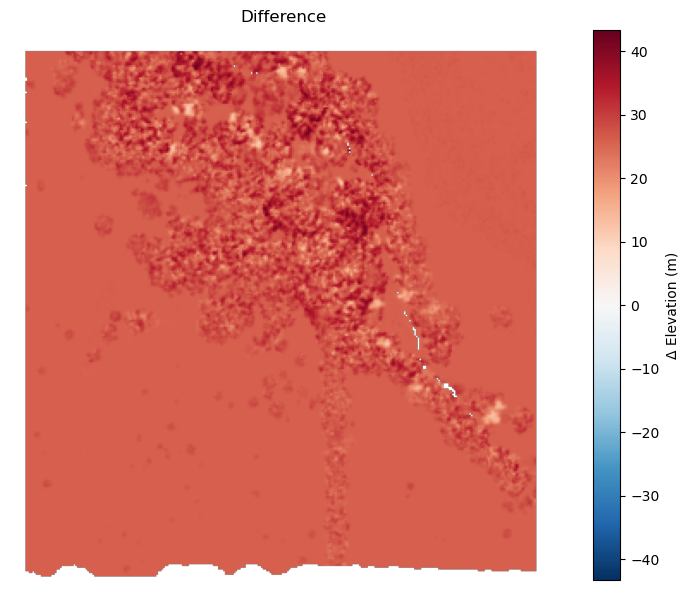

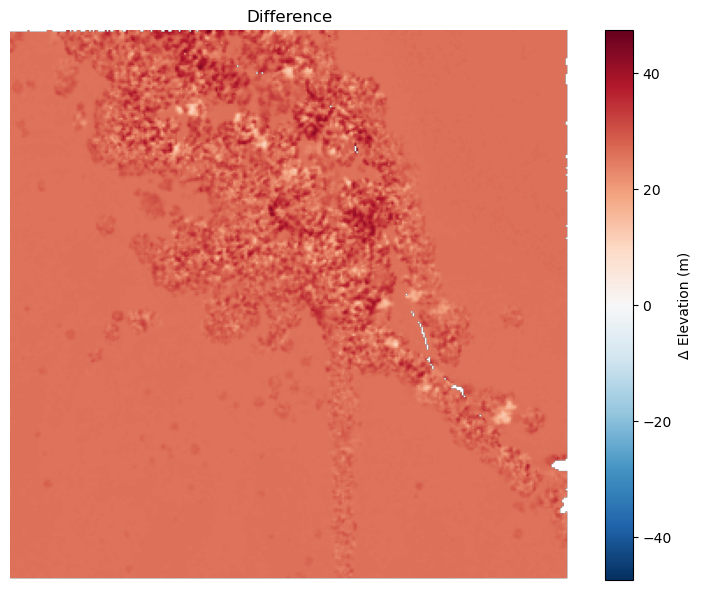

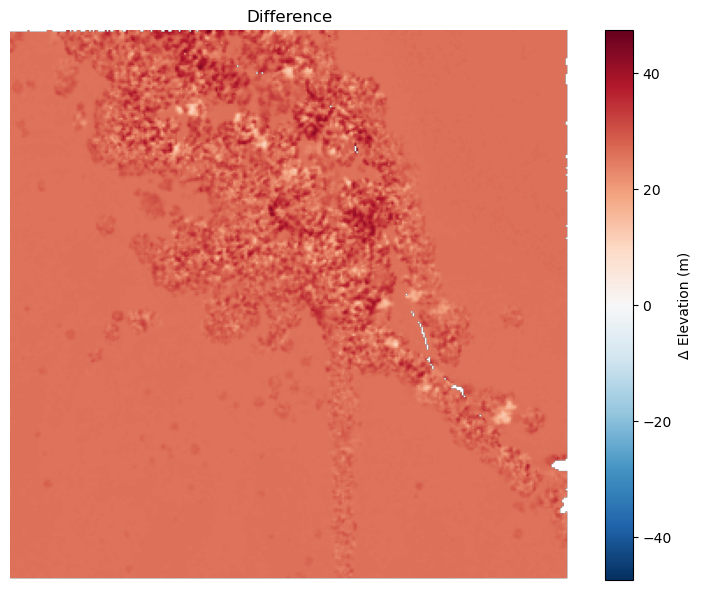

In [24]:
output_dir = get_data_path("dem_output")
os.makedirs(output_dir, exist_ok=True)

# Scenario 1: Horizontal-only (NOT aligned)
results_horizontal_only = pc_pair.compute_2d_difference(
    dem1="dsm",
    dem2="dsm",
    overwrite=True,
    diff_output_path=os.path.join(output_dir, "diff_horizontal_only.tif"),
    verbose=True,
)
raster_pair_horizontal_only = results_horizontal_only['raster_pair']

# Scenario 2: Fully transformed (NOT aligned)
results_transformed = pc_pair.compute_2d_difference(
    dem1="dsm_transformed",
    dem2="dsm",
    skip_epoch=True,
    overwrite=True,
    diff_output_path=os.path.join(output_dir, "diff_transformed.tif"),
    verbose=True,
)
raster_pair_transformed = results_transformed['raster_pair']

# Scenario 3: Fully transformed + ICP aligned
results_aligned = pc_pair.compute_2d_difference(
    dem1="dsm_transformed_aligned",
    dem2="dsm",
    skip_epoch=True,
    overwrite=True,
    diff_output_path=os.path.join(output_dir, "diff_aligned.tif"),
    verbose=True,
)
raster_pair_aligned = results_aligned['raster_pair']

print(f"\n--- 2D Difference Statistics (Aligned) ---")
print(f"Mean: {results_aligned['stats']['mean']:.4f} m")
print(f"Median: {results_aligned['stats']['median']:.4f} m")
print(f"Std: {results_aligned['stats']['std']:.4f} m")

print(f"\n--- 2D Difference Statistics (Transformed) ---")
print(f"Mean: {results_transformed['stats']['mean']:.4f} m")
print(f"Median: {results_transformed['stats']['median']:.4f} m")
print(f"Std: {results_transformed['stats']['std']:.4f} m")

print(f"\n--- 2D Difference Statistics (Unaligned) ---")
print(f"Mean: {results_horizontal_only['stats']['mean']:.4f} m")
print(f"Median: {results_horizontal_only['stats']['median']:.4f} m")
print(f"Std: {results_horizontal_only['stats']['std']:.4f} m")

# Plot
fig = raster_pair_aligned.plot_difference()
fig = raster_pair_transformed.plot_difference()
fig = raster_pair_horizontal_only.plot_difference()

In [25]:
# Use the aligned scenario for all downstream analysis
pair = raster_pair_aligned
results = results_aligned

<h2><a id="visualization"></a>4. Visualization and Derived Rasters</h2>

This section focuses on visualizing the results and creating derived topographic products like hillshades and slope maps, which are useful for interpreting the observed changes.

<h3><a id="plot-dems"></a>Plot the DEMs and derived rasters</h3>

/opt/anaconda3/envs/crs_transformation/lib/python3.13/site-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)


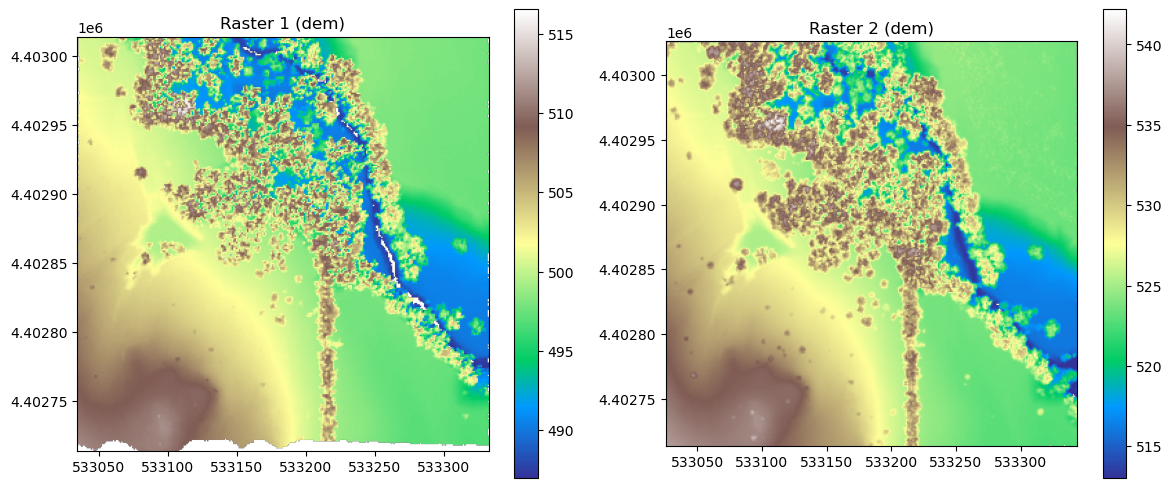

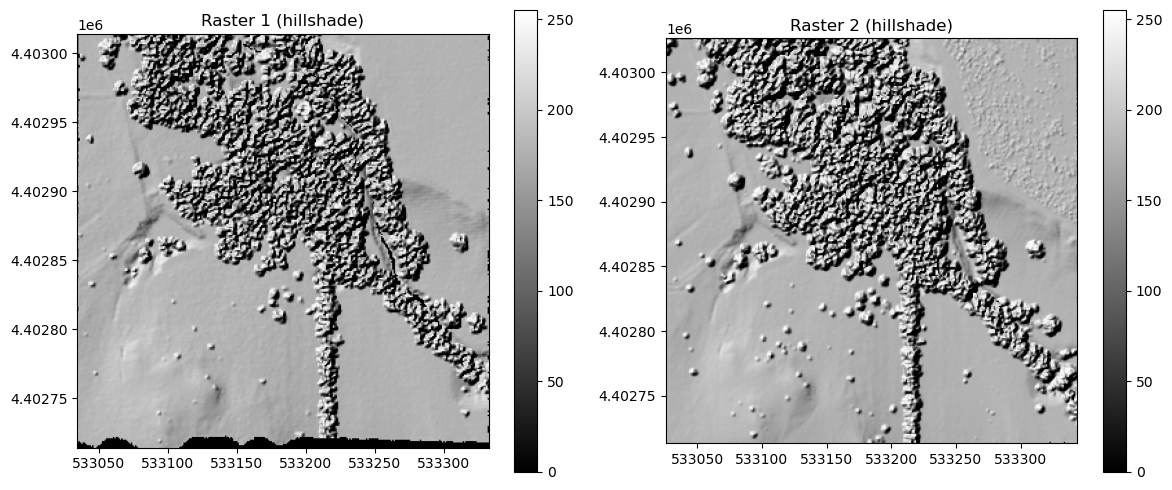

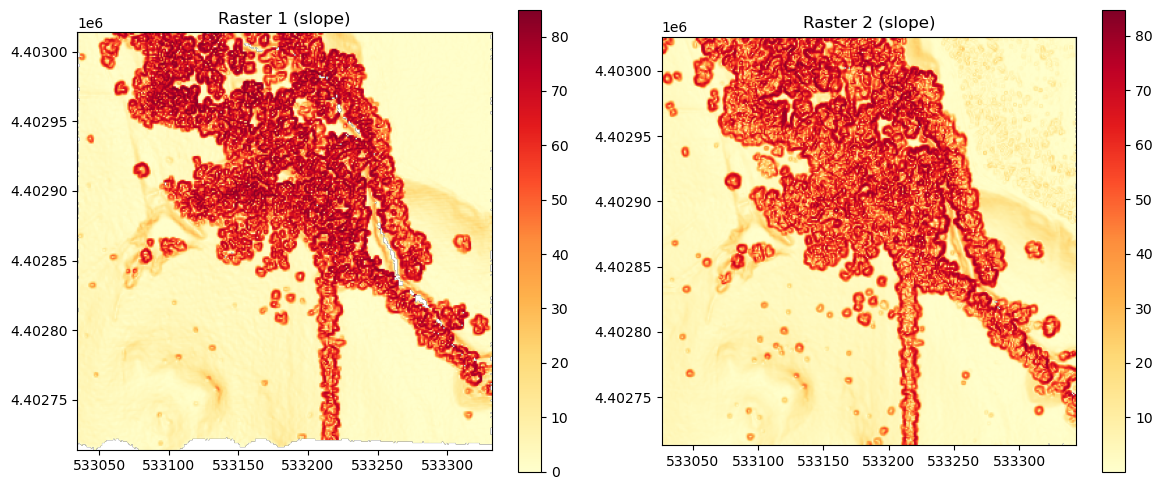

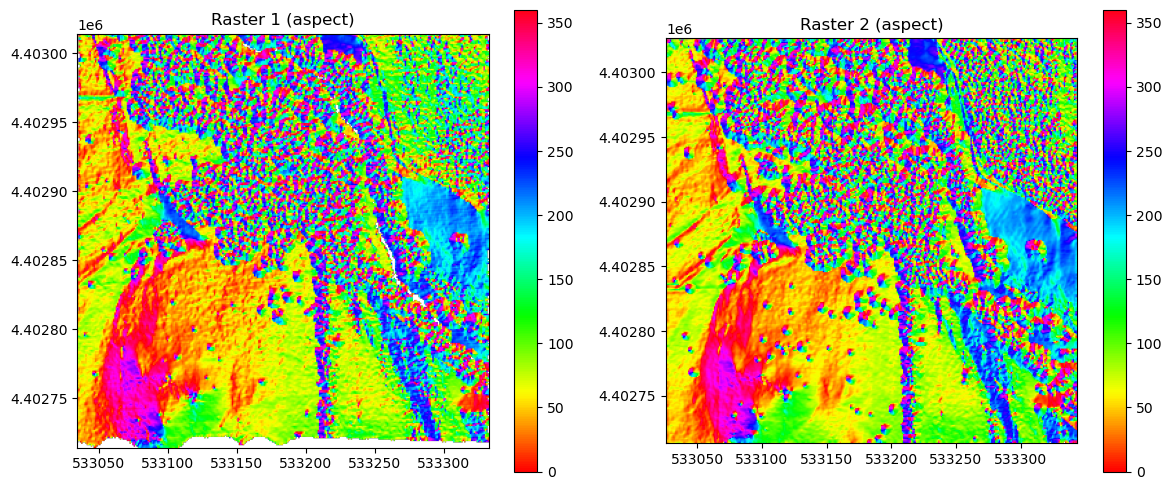

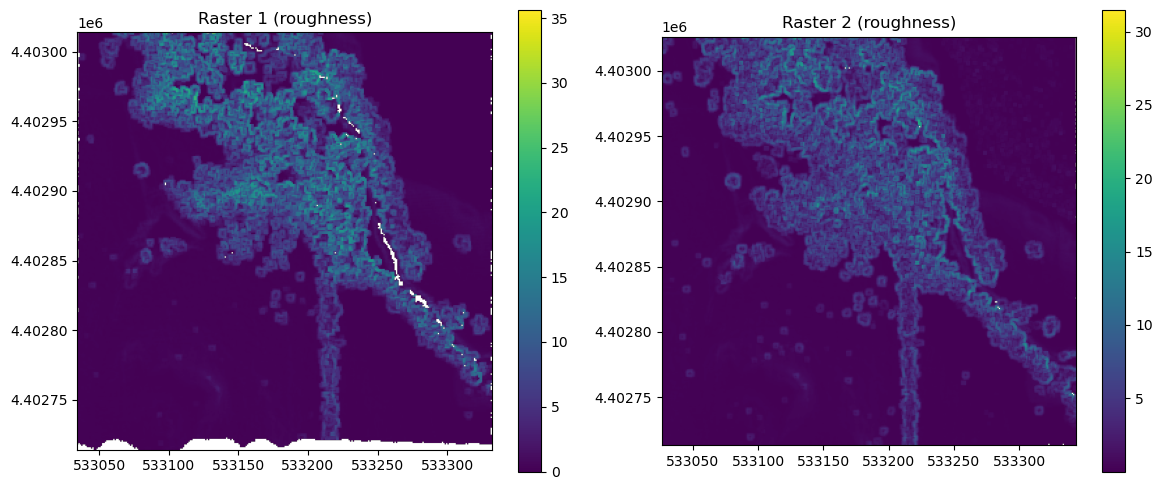

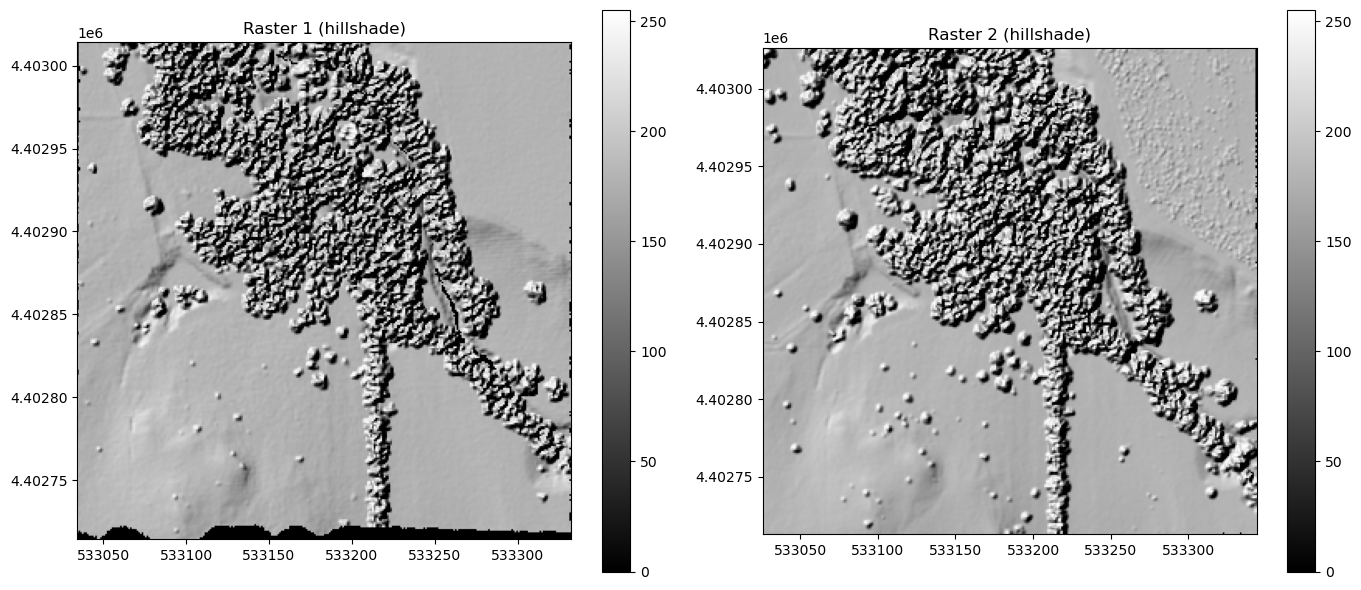

In [26]:
# Generate derivatives for both rasters
hillshade1, hillshade2 = pair.generate_derivative("hillshade")
slope1, slope2 = pair.generate_derivative("slope")
aspect1, aspect2 = pair.generate_derivative("aspect")
roughness1, roughness2 = pair.generate_derivative("roughness")

# Plot side-by-side with automatic derivative generation
fig, axes = pair.plot_pair(derivative='dem')        # Original DEMs
fig, axes = pair.plot_pair(derivative='hillshade')  # Hillshades
fig, axes = pair.plot_pair(derivative='slope')      # Slopes
fig, axes = pair.plot_pair(derivative='aspect')     # Aspects
fig, axes = pair.plot_pair(derivative='roughness')  # Roughness

# Customize hillshade parameters
fig, axes = pair.plot_pair(
    derivative='hillshade',
    azimuth=270,    # West-facing light
    altitude=30,    # Low sun angle
    figsize=(14, 6)
)

/Users/cassandrabrigham/ASU Dropbox/Cassandra Brigham/Mac/Documents/POSTDOC/Code/topographic-differencing-uncertainty/src/topochange/raster.py:1962: RuntimeWarning: invalid value encountered in divide
  interp = np.where(weight_sum > 0, weighted_sum / weight_sum, np.nan)
/opt/anaconda3/envs/crs_transformation/lib/python3.13/site-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)


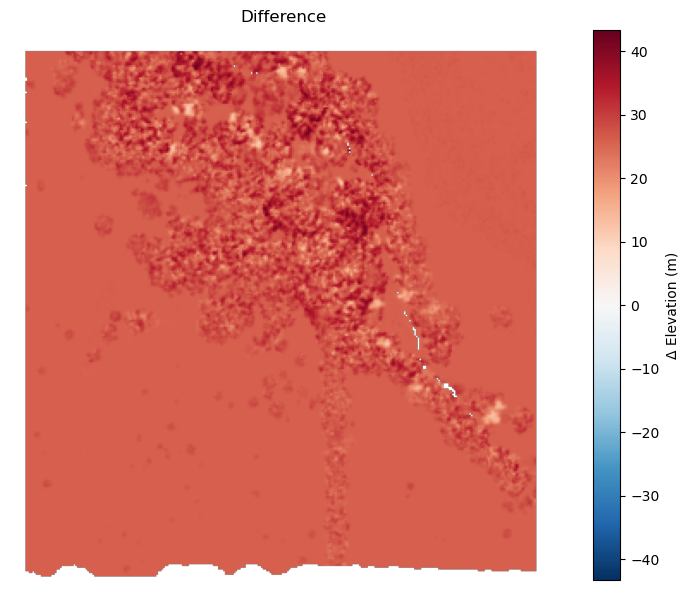

In [27]:
pair.plot_difference()

<h2><a id="error_analysis"></a>5. Error analysis</h2>

<h3><a id="theoretical_framework"></a>Theoretical framework</h3>

The error analysis framework implemented here follows the geostatistical approach described by [Rolstad et al., 2009](https://doi.org/10.3189/002214309789470950) and [Hugonnet et al., 2022](https://doi.org/10.1109/JSTARS.2022.3188922), adapted for lidar-derived topographic differencing.

Topographic differencing errors can be decomposed into three components:

1. **Systematic vertical bias** (μ): A constant offset between datasets, typically estimated as the median of stable-area differences to reduce outlier influence

2. **Spatially correlated random error**: Errors that exhibit spatial structure due to:
   - Point misclassification (meter to decameter scale)
   - Geometric distortion on slopes (decameter scale)
   - Horizontal alignment errors (hundred-meter scale)
   - Flight line striping (hundred-meter to kilometer scale)
   - Vertical datum inconsistencies (kilometer scale)

3. **Uncorrelated random noise** (nugget): High-frequency noise from sensor sensitivity, environmental conditions, and surface reflectivity ([Glennie, 2007](https://doi.org/10.1515/jag.2007.017))

The semivariogram γ(h) quantifies how the variance of differences increases with separation distance h (Matheron, 1965; [Webster & Oliver, 2007](https://doi.org/10.1002/9780470517277)):

$$\gamma(h) = \frac{1}{2N(h)} \sum_{i=1}^{N(h)} [\Delta_z(x_i) - \Delta_z(x_i + h)]^2$$

Key variogram parameters:
- **Nugget (c₀)**: Discontinuity at origin representing uncorrelated noise
- **Sill (c)**: Plateau value representing total variance
- **Range (a)**: Distance at which spatial correlation decays to negligible levels

For lidar data, **nested variograms** with multiple components capture error structures at different scales. Each spatial scale (short, medium, long range) contributes a portion of the total error variance.

<h3><a id="define_stable_areas"></a>Define stable areas</h3>


Stable areas are regions where **no topographic change is expected** between surveys. They serve as control zones for error calibration and the elevation differences within these areas represent pure error, allowing us to characterize the spatial structure of uncertainty.

<h4><a id="size_requirements"></a>Size requirements</h4>

The stable area must be large enough to reliably estimate the empirical variogram. Key constraints include (Journel & Huijbregts, 1978; [Oliver & Webster, 2015](https://doi.org/10.1007/978-3-319-15865-5)):

<h5><a id="min_pairs"></a>1. Minimum pairs per lag bin</h5>
Each lag bin in the variogram requires **at least 30 pairs**, with 50+ pairs recommended. Fewer than 20 pairs per bin produces unreliable estimates with high variance.

<h5><a id="var_coverage"></a>2. Variogram coverage rule</h5>
The variogram should span **less than half the domain size** to avoid pairing samples from opposite edges (Journel & Huijbregts, 1978). This means that if you expect correlation ranges up to 500 m, your stable area should have at least a 1 km extent in its longest dimension.

<h5><a id="corr_scales"></a>3. Capturing all correlation scales</h5> 
The largest correlation scale has the greatest impact on uncertainty estimates ([Rolstad et al., 2009](https://doi.org/10.3189/002214309789470950)). Typical lidar error correlation ranges span:

- **Short-range**: 10–100 m (point classification, geometric distortion)
- **Mid-range**: 100–1000 m (horizontal alignment, flight lines)
- **Long-range**: >1 km (vertical datum, geoid errors)

Your stable areas should extend far enough to capture all relevant scales.

<h4><a id="good_stable_area"></a>What makes a good stable area?</h4> 

**Ideal choices**:
- Roads and parking lots (paved, unvegetated)
- Bedrock outcrops (geologically stable)
- Flat, undisturbed terrain
- Areas with similar terrain properties (slope, roughness) to your areas of interest

**Areas to avoid**:
- Vegetation change zones (leaf-on vs. leaf-off)
- Construction or development areas
- Water bodies (variable water levels)
- Very steep slopes (higher geometric distortion)
- DEM boundary edges (edge effects)
- Areas with real expected change

<h4><a id="heteroscedasticity_consideration"></a>Heteroscedasticity consideration</h4>

Errors can vary with terrain properties. [Hugonnet et al., 2022](https://doi.org/10.1109/JSTARS.2022.3188922) explored how error variance changes with parameters such as slope and roughness. Ideally, stable areas should have similar terrain characteristics to your areas of interest, or you should account for this heteroscedasticity in the analysis. [xDEM](https://xdem.readthedocs.io/en/stable/uncertainty.html#heteroscedasticity) offers tools to model raster heteroscedasticity.



**Use the interactive map below to draw polygons over areas you consider stable.**

**Instructions:**
1. Use the polygon tool to draw areas of no expected change
2. Select "Stable" from the layer dropdown when drawing
3. Aim for areas totaling at least 1 km² if you expect long-range correlations
4. Run the cells below after drawing your polygons

In [28]:
diff = results.get("difference_raster")

In [29]:
out_folder_poly = Path.joinpath(BASE_DATA_DIR,"polygons/")
os.makedirs(out_folder_poly, exist_ok=True)


interactor = TopoMapInteractor(
    topo_diff_path=diff.filename,
    hillshade_path=hillshade1.filename,
    output_dir=out_folder_poly,
    overlay_dpi=600,
    overlay_vmin=-20,
    overlay_vmax=20,
)

interactor.map

/opt/anaconda3/envs/crs_transformation/lib/python3.13/site-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)
Overlay: shape=(313, 318), nodata=nan
Valid pixels: 87,474 / 99,534 (87.9%)
Color range: [-20.000, 20.000]
Data range: [9.263, 44.699]
Saved overlay: your/path/here/polygons/diff_aligned-f8d41a9678e94429abf005869fd725fd.png
Generated data URL: 7090 chars (5300 bytes)
Map bounds (lat/lon): ((39.77371452799188, -98.61436854545607), (39.776522244011744, -98.610639557473))
Map center: (39.77511838600181, -98.61250405146453)
Using overlay: your/path/here/polygons/diff_aligned-f8d41a9678e94429abf005869fd725fd.png


Map(center=[39.77511838600181, -98.61250405146453], controls=(ZoomControl(options=['position', 'zoom_in_text',…

In [30]:
interactor.stable_geoms

[<POLYGON ((533089.721 4402942.082, 533096.601 4402776.739, 533299.758 440275...>]

In [31]:
interactor.unstable_geoms

[]

<h3><a id="descriptive_stats"></a>Descriptive statistics</h3>

Before fitting a variogram, it is essential to examine the statistical characteristics of the stable area(s). Descriptive statistics provide a first-order assessment of the differencing errors and help evaluate whether the data meet the assumptions required for geostatistical analysis.

**Key statistics to examine:**

- **Mean and Median**: The median of the elevation differences in stable areas estimates the systematic vertical bias between the two DEMs. A non-zero median indicates a consistent offset that should be removed before variogram analysis. The mean is more sensitive to outliers, so comparing mean and median helps identify skewness in the distribution.

- **Standard Deviation and Variance**: These quantify the overall spread of elevation differences. High variance may indicate significant error sources or residual real change in areas assumed to be stable.

- **Skewness and Kurtosis**: Departures from normality can signal issues. Positive skewness might indicate unremoved vegetation or construction, while heavy tails (high kurtosis) could reflect outliers from misclassification or edge effects.

- **Percentiles (0.5%, 99.5%)**: Examining extreme percentiles helps identify outliers that may need to be filtered before variogram estimation.

**Assessing stationarity across stable areas:**

A fundamental assumption in geostatistics is *stationarity* — that the mean and variance of the error field are constant across the study area, and that spatial covariance depends only on separation distance, not absolute location ([Webster & Oliver, 2007](https://doi.org/10.1002/9780470517277)). Examining the statistics of each stable area *separately* provides a practical check:

1. **Compare means/medians across areas**: Substantially different median values may indicate spatially varying bias (e.g., from flight line effects or tilted datums), violating the assumption that a single variogram model applies everywhere.

2. **Compare variances across areas**: If one stable area has much higher variance than another, the error characteristics may depend on location or terrain properties. This *heteroscedasticity* suggests that a single variogram may not adequately represent error structure across the entire scene ([Hugonnet et al., 2022](https://doi.org/10.1109/JSTARS.2022.3188922)).

3. **Look for systematic patterns**: If stable areas on one side of the scene consistently show positive differences while those on the other side show negative differences, a regional trend or tilt may be present that should be modeled separately.

The table and histogram below summarize the distribution of elevation differences in your stable area(s). If you have defined multiple stable polygons, compare their individual statistics to assess spatial consistency.

In [32]:
stable_polys, _ = interactor.export_geodataframes()

# one combined mask
rasterizer_stable = StableAreaRasterizer(interactor.topo_diff.path, stable_polys, nodata=-9999)
analyzer_stable = StableAreaAnalyzer(rasterizer_stable)

# Combined-area stats
df_all_stable_polys = analyzer_stable.stats_all(Path.joinpath(BASE_DATA_DIR,"polygons/combined_stable.tif"))

# Per-area stats
df_each_stable_poly = analyzer_stable.stats_each(Path.joinpath(BASE_DATA_DIR,"polygons/each_stable/"))


In [33]:
df_all_stable_polys

,mean,median,mode,std,variance,min,max,skewness,kurtosis,0.5_percentile,99.5_percentile
all_areas,26.757513,25.915833,25.889038,2.596465,6.741631,9.263397,44.217865,1.221251,5.659968,18.661733,37.4238


In [34]:
df_each_stable_poly

,mean,median,mode,std,variance,min,max,skewness,kurtosis,0.5_percentile,99.5_percentile
area_id,,,,,,,,,,,
0,26.757513,25.915833,25.889038,2.596465,6.741631,9.263397,44.217865,1.221251,5.659968,18.661733,37.4238


<h3><a id="estimate-error"></a>Estimate systematic error</h3>


Systematic error (vertical bias) represents a constant offset between the two DEMs that affects all elevation differences uniformly. This bias can arise from instrument calibration errors, incorrect atmospheric corrections, GNSS/IMU misalignments, or inconsistencies in vertical coordinate reference systems such as mismatched geoid models ([Glennie, 2007](https://doi.org/10.1515/jag.2007.017); [Habib et al., 2009](https://doi.org/10.14358/PERS.75.10.1159)). Geoid errors typically produce shifts of 10–20 cm, while confusion between ellipsoidal and orthometric heights can cause offsets of tens of meters.

**Why use the median?**

We estimate vertical bias as the **median** of elevation differences in stable areas rather than the mean. The median is more robust to outliers(isolated large values from real change, misclassification, or edge effects—ensuring the bias estimate reflects the typical offset rather than being skewed by anomalous values) (Brigham et al.)

**Interpreting the bias:**

- A non-zero median indicates systematic offset that should be removed before variogram analysis
- The bootstrap uncertainty quantifies confidence in the bias estimate
- After bias removal, the distribution should be approximately centered on zero

**Important considerations:**

- If you observe widespread real change (e.g., regional uplift from an earthquake or isostatic rebound), this signal will be absorbed into the bias estimate and must be accounted for separately
- For DSM differencing, vegetation changes (leaf-on vs. leaf-off) can bias the median; consider estimating bias from DTM results instead
- Very large biases (>1 m) may indicate datum errors that should be investigated before proceeding

In [35]:

# Load the stable area raster (this is the masked difference raster)
stable_area_path = Path.joinpath(BASE_DATA_DIR, "polygons/combined_stable.tif")
stable_area = Raster.from_file(stable_area_path)

# Get the median from the stable area
# Read the data directly with rasterio to get valid values

with rasterio.open(stable_area_path) as src:
    data = src.read(1)
    nodata = src.nodata
    # Mask nodata values
    if nodata is not None:
        valid_data = data[data != nodata]
    else:
        valid_data = data[np.isfinite(data)]
    
    diff_stable_median = np.median(valid_data)
    print(f"Median of stable area differences: {diff_stable_median:.4f} m")

# Set up paths and parameters
output_path = Path.joinpath(BASE_DATA_DIR, "polygons/combined_stable_bias_removed.tif")
unit = "m"
dem_resolution = 1.0

# Load raster data using RasterDataHandler
raster_data_handler = RasterDataHandler(stable_area_path, unit, dem_resolution)
raster_data_handler.load_raster()

# Get the data array
vert_diff_array = raster_data_handler.data_array

# Measure of vertical bias (median)
vertical_bias = np.median(vert_diff_array)
print(f"Vertical bias: {vertical_bias:.4f} m")

# Get uncertainty in the median value by bootstrap resampling
stats = StatisticalAnalysis(raster_data_handler)
median_uncertainty = stats.bootstrap_uncertainty_subsample(n_bootstrap=1000, subsample_proportion=0.1)
print(f"Median uncertainty (bootstrap): {median_uncertainty:.4f} m")

# Subtract the vertical bias from the stable area raster and save
raster_data_handler.subtract_value_from_raster(output_path, vertical_bias)
print(f"Saved bias-removed raster to: {output_path}")

# Create new RasterDataHandler for the modified raster
raster_bias_removed = RasterDataHandler(output_path, unit, dem_resolution)
raster_bias_removed.load_raster()

print(f"\nBias-removed stats:")
print(f"  Mean: {np.mean(raster_bias_removed.data_array):.4f} m")
print(f"  Median: {np.median(raster_bias_removed.data_array):.4f} m")
print(f"  Std: {np.std(raster_bias_removed.data_array):.4f} m")

Median of stable area differences: nan m
Vertical bias: 25.9158 m
Median uncertainty (bootstrap): 0.0030 m
Saved bias-removed raster to: your/path/here/polygons/combined_stable_bias_removed.tif

Bias-removed stats:
  Mean: 0.8417 m
  Median: 0.0000 m
  Std: 2.5965 m


/opt/anaconda3/envs/crs_transformation/lib/python3.13/site-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)


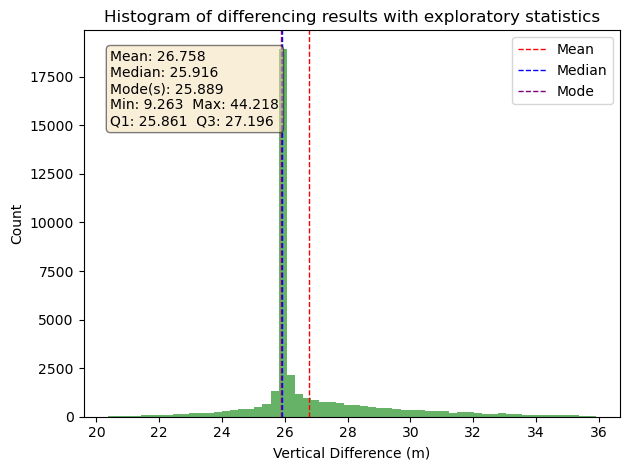

In [36]:
fig = stats.plot_data_stats()

<h3><a id="Variography"></a>Variography</h3>


Variography is the process of estimating and modeling the spatial covariance structure of your data. For topographic differencing, we analyze how elevation errors are correlated across space ([Webster & Oliver, 2007](https://doi.org/10.1002/9780470517277); [Oliver & Webster, 2014](https://doi.org/10.1016/j.catena.2013.09.006)).

<h4><a id="semivariogram"></a>The semivariogram</h4>

The **semivariogram** γ(h) measures the average squared difference between values separated by distance h (Matheron, 1965):

$$\gamma(h) = \frac{1}{2N(h)} \sum_{i=1}^{N(h)} [z(x_i) - z(x_i + h)]^2$$

At small distances, nearby points tend to have similar errors (low semivariance). As distance increases, the correlation breaks down and semivariance increases until it reaches a plateau (the sill).

The variogram has several key features:

1. **Nugget (c₀)**: The y-intercept, representing measurement noise and microscale variability below the sampling resolution

2. **Sill (c)**: The plateau value representing total variance. When the variogram reaches the sill, points are no longer spatially correlated.

3. **Range (a)**: The distance at which the sill is reached. Beyond this distance, errors are independent.

<h4><a id="nested_variogram"></a>Nested variograms for multi-scale error</h4> 

Lidar differencing errors operate at multiple scales simultaneously. A **nested variogram** captures this:

$$\gamma(h) = c_0 + \sum_{i=1}^{n} c_i \cdot \text{model}_i(h, a_i)$$

where each component (i) has its own partial sill (cᵢ) and range (aᵢ). For example:
- Component 1 (range ~30 m): Point classification errors
- Component 2 (range ~500 m): Flight line alignment errors
- Component 3 (range ~2 km): Geoid/datum inconsistencies

<h4><a id="model_selection"></a>Model Selection</h4>

We fit nested spherical models and select the best using:
- **AIC (Akaike Information Criterion)**: Balances fit quality vs. model complexity
- **Cross-validation**: Tests predictive performance on held-out data

The spherical model is commonly used because it has a finite range, provides smooth transitions, and handles nesting well ([Webster & Oliver, 2007](https://doi.org/10.1002/9780470517277)).

<h4><a id="sampling"></a>Sampling for computational efficiency</h4>

Computing all pairwise distances for a large raster is computationally prohibitive. We use:
- **Stratified random sampling**: Divide the raster into sub-grids and sample uniformly
- **Multiple realizations**: Repeat sampling ~30 times to estimate confidence bounds ([Ortiz & Deutsch, 2002](https://doi.org/10.1023/A:1014412218427))
- **Numba JIT compilation**: Accelerates the pairwise calculations

In [37]:
#Create variogram analysis instance based on modified raster
V = VariogramAnalysis(raster_bias_removed)

#Calculate a mean variogram with 75 bins from variograms made over 10 runs
V.calculate_mean_variogram_numba(area_side = 250, samples_per_area = 400, max_samples = 1000000000, bin_width = 30, max_n_bins = 3000, n_runs = 30, max_lag_multiplier = 0.5)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
/Users/cassandrabrigham/ASU Dropbox/Cassandra Brigham/Mac/Documents/POSTDOC/Code/topographic-differencing-uncertainty/src/topochange/variogram.py:1172: RuntimeWarning: Mean of empty slice
  mean_variogram = np.nanmean(vario_arr, axis=0)
/opt/anaconda3/envs/crs_transformation/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/Users/cassandrabrigham/ASU Dropbox/Cassandra Brigham/Mac/Documents/POSTDOC/Code/topographic-differencing-uncertainty/src/topochange/variogram.py:1176: RuntimeWarning: Mean of empty slice
  mean_count = np.nanmean(count_arr, axis=0)
/opt/anaconda3/envs/crs_transformation/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [41]:
# Multi-model fitting, compare spherical, exponential, gaussian, matern
print("=" * 70)
print("MULTI-MODEL VARIOGRAM FITTING")
print("=" * 70)

# Fit all candidate models and select best by AIC
best_model = V.fit_best_model_auto(
    model_types=['spherical', 'exponential', 'gaussian', 'matern'],
    max_components=3,
    include_nugget=False,
    criterion='bic',
    compute_cv=True,
    n_bootstrap=500,
    seed=SEED,
)

print(f"\nBest model: {'+'.join(best_model.composite_model.component_names)}")
print(f"AIC: {best_model.aic:.2f}")
print(f"BIC: {best_model.bic:.2f}")
print(f"CV-RMSE: {best_model.cv_rmse:.4f}" if best_model.cv_rmse else "CV-RMSE: N/A")

# Print model parameters
print(f"\n{'─' * 40}")
print("Model Parameters:")
print(f"{'─' * 40}")
cm = best_model.composite_model
print(f"  Nugget: {cm.get_nugget():.6f}")
for i, name in enumerate(cm.component_names):
    comp_params = cm.get_component_params(i)
    param_names = cm.param_names
    # Each component has sill, range (and possibly extra params like nu for matern)
    print(f"\n  Component {i+1}: {name}")
    print(f"    Sill:  {comp_params[0]:.6f}")
    print(f"    Range: {comp_params[1]:.6f}")
    if len(comp_params) > 2:
        for j, val in enumerate(comp_params[2:], start=2):
            print(f"    Param {j}: {val:.6f}")
print(f"\n  Total sill: {cm.get_total_sill():.6f}" if cm.get_total_sill() is not None else "\n  Total sill: N/A (unbounded model)")

MULTI-MODEL VARIOGRAM FITTING


/Users/cassandrabrigham/ASU Dropbox/Cassandra Brigham/Mac/Documents/POSTDOC/Code/topographic-differencing-uncertainty/src/topochange/variogram.py:395: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(



Best model: spherical
AIC: 84.29
BIC: 84.69
CV-RMSE: 2.9750

────────────────────────────────────────
Model Parameters:
────────────────────────────────────────
  Nugget: 0.000000

  Component 1: spherical
    Sill:  4.239700
    Range: 6.002544

  Total sill: 4.239700


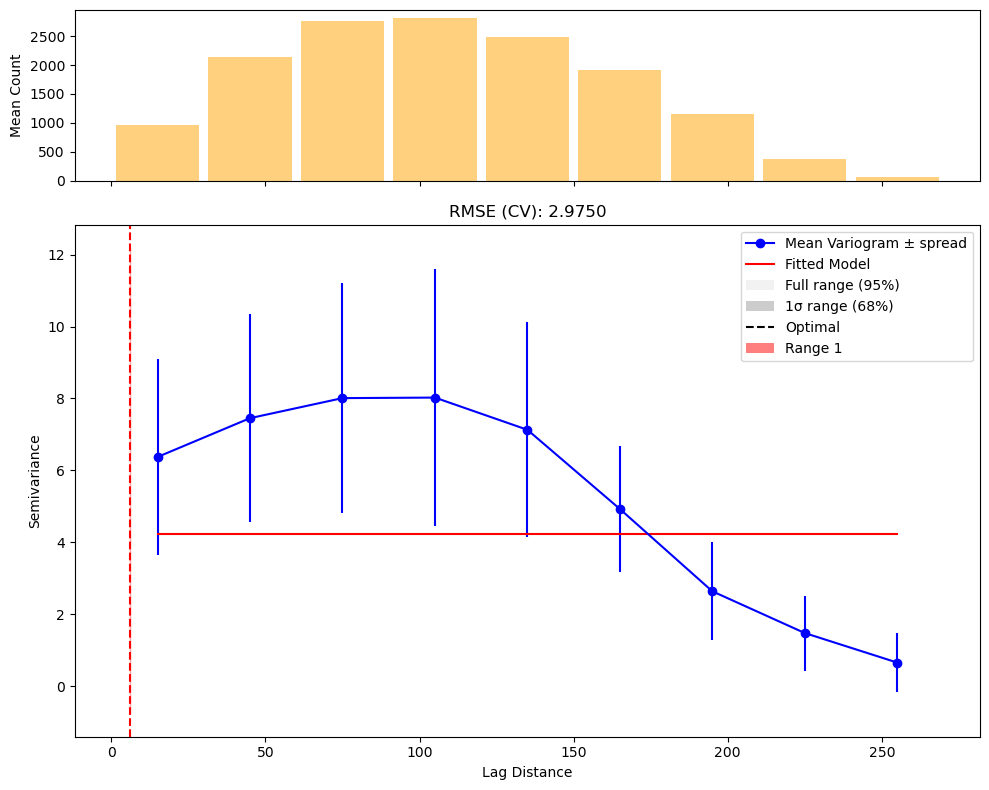

In [43]:
fig = V.plot_best_model()

<h3><a id="uncertainty_propagation"></a>Uncertainty propagation</h3>

Once we have a fitted variogram model, we can propagate uncertainty to any area of interest ([Rolstad et al., 2009](https://doi.org/10.3189/002214309789470950)). This is the key step that transforms error characterization into actionable uncertainty bounds.

For a spatially averaged elevation change over an area A, the regional variance σ²_A depends on the spatial covariance structure:

$$\sigma_A^2 = \frac{1}{A^2} \int_A \int_A [\sigma_{\Delta_z}^2 - \gamma(h)] \, dx \, dy$$

**Intuition**: If all points in your area are highly correlated (small area relative to the range), errors move together and uncertainty is high. If points are spread over a large area with mixed positive and negative errors that partially cancel, uncertainty decreases.

A crucial insight: **uncertainty decreases as the area of aggregation increases**, but at different rates depending on the variogram parameters:
- Features smaller than the correlation range: errors are correlated and don't cancel out (uncertainty ≈ √sill)
- Features much larger than the correlation range: errors average toward zero (uncertainty ≈ √(sill / n_effective))

With a nested variogram, each component contributes independently:

$$\sigma_{total}^2 = \sigma_{nugget}^2 + \sigma_{short}^2 + \sigma_{mid}^2 + \sigma_{long}^2$$

For irregularly shaped polygons, we use **Monte Carlo integration**: randomly sample N pairs of points within the polygon, compute covariances using the fitted variogram, and average to approximate the double integral (~10,000–25,000 pairs).

<h4><a id="features_of_interest"></a>Draw features of interest (unstable areas)</h4> 

Use the interactive map below to draw polygons around areas where you expect topographic change (e.g., landslides, construction sites, eroded channels, deposited sediment bars). The uncertainty will be calculated for each polygon.

In [44]:
interactor.map

Map(bottom=12730724.0, center=[39.775132300039616, -98.61250877380373], controls=(ZoomControl(options=['positi…

In [46]:
interactor.unstable_geoms

[<POLYGON ((533180.827 4402846.693, 533189.229 4402824.753, 533213.075 440283...>]

In [47]:
_, unstable_polys = interactor.export_geodataframes()

In [49]:
# Calculate uncertainty for each feature of interest
# Pass fitted_model so any variogram model type (spherical, matern, hole_effect, etc.) is supported

uncertainties_per_feature = []

for i, poly in enumerate(unstable_polys['geometry']):
    print(f"\nProcessing polygon {i+1}/{len(unstable_polys)}...")

    estimator = RegionalUncertaintyEstimator(
        raster_data_handler=raster_bias_removed,
        variogram_analysis=V,
        area_of_interest=poly,
        fitted_model=V.fitted_model,
    )

    estimator.calc_total_uncertainty(n_pairs=25_000, seed=SEED)
    uncertainties_per_feature.append(estimator)

# Print detailed summary for first polygon
print("\n")
print(uncertainties_per_feature[0].summary())


Processing polygon 1/1...


REGIONAL UNCERTAINTY SUMMARY
Polygon area: 308.18 m²
Total variance (σ²): 4.239700; min: 3.391760; max: 5.087640

Uncorrelated σ₀: 2.729479
Uncorrelated (polygon mean): 0.155482

POLYGON CORRELATED UNCERTAINTY:
  Total: 1.338642; min: 0.000000; max: 0.000000

POLYGON TOTAL UNCERTAINTY:
  Total: 1.347642; min: 0.155482; max: 0.155482

----------------------------------------------------------------------
RASTER CORRELATED UNCERTAINTY:
  Uncorrelated (raster mean): 0.013572
  Total: 0.000000; min: 0.000000; max: 0.000000

RASTER TOTAL UNCERTAINTY:
  Total: 0.013572; min: 0.013572; max: 0.013572


---

<h2><a id="references"></a>References</h2>

- Albino, F., Smets, B., d'Oreye, N. & Kervyn, F. (2015). High‐resolution TanDEM‐X DEM: An accurate method to estimate lava flow volumes at Nyamulagira Volcano (D.R. Congo). *Journal of Geophysical Research: Solid Earth*, 120, 4189–4207. [https://doi.org/10.1002/2015JB011988](https://doi.org/10.1002/2015JB011988)

- Anderson, S.W. (2019). Uncertainty in quantitative analyses of topographic change: error propagation and the role of thresholding. *Earth Surface Processes and Landforms*, 44, 1015–1033. [https://doi.org/10.1002/esp.4551](https://doi.org/10.1002/esp.4551)

- Besl, P.J. & McKay, N.D. (1992). Method for registration of 3-D shapes. *Sensor Fusion IV: Control Paradigms and Data Structures*, SPIE, 586–606. [https://doi.org/10.1117/12.57955](https://doi.org/10.1117/12.57955)

- Brasington, J. & Smart, R.M.A. (2003). Close range digital photogrammetric analysis of experimental drainage basin evolution. *Earth Surface Processes and Landforms*, 28, 231–247. [https://doi.org/10.1002/esp.480](https://doi.org/10.1002/esp.480)

- Brasington, J., Langham, J. & Rumsby, B. (2003). Methodological sensitivity of morphometric estimates of coarse fluvial sediment transport. *Geomorphology*, 53, 299–316. [https://doi.org/10.1016/S0169-555X(02)00320-3](https://doi.org/10.1016/S0169-555X(02)00320-3)

- Dehecq, A., Gardner, A.S., Alexandrov, O., McMichael, S., Hugonnet, R., Shean, D. & Marty, M. (2020). Automated Processing of Declassified KH-9 Hexagon Satellite Images for Global Elevation Change Analysis Since the 1970s. *Frontiers in Earth Science*, 8, 566802. [https://doi.org/10.3389/feart.2020.566802](https://doi.org/10.3389/feart.2020.566802)

- Glennie, C.L., Hinojosa‐Corona, A., Nissen, E., Kusari, A., Oskin, M.E., Arrowsmith, J.R. & Borsa, A. (2014). Optimization of legacy lidar data sets for measuring near‐field earthquake displacements. *Geophysical Research Letters*, 41, 3494–3501. [https://doi.org/10.1002/2014GL059919](https://doi.org/10.1002/2014GL059919)

- Glennie, C. (2007). Rigorous 3D error analysis of kinematic scanning LIDAR systems. *Journal of Applied Geodesy*, 1, 147–157. [https://doi.org/10.1515/jag.2007.017](https://doi.org/10.1515/jag.2007.017)

- Heritage, G.L., Milan, D.J., Large, A.R.G. & Fuller, I.C. (2009). Influence of survey strategy and interpolation model on DEM quality. *Geomorphology*, 112, 334–344. [https://doi.org/10.1016/j.geomorph.2009.06.024](https://doi.org/10.1016/j.geomorph.2009.06.024)

- Hugonnet, R., Brun, F., Berthier, E., Dehecq, A., Mannerfelt, E.S., Eckert, N. & Farinotti, D. (2022). Uncertainty analysis of digital elevation models by spatial inference from stable terrain. *IEEE Journal of Selected Topics in Applied Earth Observations and Remote Sensing*, 15, 6456–6472. [https://doi.org/10.1109/JSTARS.2022.3188922](https://doi.org/10.1109/JSTARS.2022.3188922)

- Izumida, A., Uchiyama, S. & Sugai, T. (2017). Application of UAV-SfM photogrammetry and aerial lidar to a disastrous flood: repeated topographic measurement of a midstream 2 river during a recovery. *Natural Hazards and Earth System Sciences*, 17, 1505–1519. [https://doi.org/10.5194/nhess-17-1505-2017](https://doi.org/10.5194/nhess-17-1505-2017)

- Journel, A.G. & Huijbregts, C.J. (1978). *Mining Geostatistics*. Academic Press.

- Lane, S.N., Westaway, R.M. & Hicks, D.M. (2003). Estimation of erosion and deposition volumes in a large, gravel‐bed, braided river using synoptic remote sensing. *Earth Surface Processes and Landforms*, 28, 249–271. [https://doi.org/10.1002/esp.483](https://doi.org/10.1002/esp.483)

- Langridge, R.M., Ries, W.F., Farrier, T., Barth, N.C., Khajavi, N. & De Pascale, G.P. (2014). Developing sub 5-m lidar DEMs for forested sections of the Alpine and Hope faults, South Island, New Zealand. *Geomorphology*, 226, 226–240. [https://doi.org/10.1016/j.geomorph.2014.08.007](https://doi.org/10.1016/j.geomorph.2014.08.007)

- Lucieer, A., de Jong, S.M. & Turner, D. (2014). Mapping landslide displacements using Structure from Motion (SfM) and image correlation of multi-temporal UAV photography. *Progress in Physical Geography*, 38, 97–116. [https://doi.org/10.1177/0309133313515293](https://doi.org/10.1177/0309133313515293)

- Matheron, G. (1965). *Les variables régionalisées et leur estimation*. Masson, Paris.

- Oliver, M.A. & Webster, R. (2014). A tutorial guide to geostatistics: Computing and modelling variograms and kriging. *Catena*, 113, 56–69. [https://doi.org/10.1016/j.catena.2013.09.006](https://doi.org/10.1016/j.catena.2013.09.006)

- Oliver, M.A. & Webster, R. (2015). *Basic Steps in Geostatistics: The Variogram and Kriging*. Springer. [https://doi.org/10.1007/978-3-319-15865-5](https://doi.org/10.1007/978-3-319-15865-5)

- Ortiz, J.M. & Deutsch, C.V. (2002). Calculation of uncertainty in the variogram. *Mathematical Geology*, 34(2), 169–183. [https://doi.org/10.1023/A:1014412218427](https://doi.org/10.1023/A:1014412218427)

- Passalacqua, P., Belmont, P., Staley, D.M. et al. (2015). Analyzing high resolution topography for advancing the understanding of mass and energy transfer through landscapes: A review. *Earth-Science Reviews*, 148, 174–193. [https://doi.org/10.1016/j.earscirev.2015.05.012](https://doi.org/10.1016/j.earscirev.2015.05.012)

- Rolstad, C., Haug, T. & Denby, B. (2009). Spatially integrated geodetic glacier mass balance and its uncertainty based on geostatistical analysis: application to the western Svartisen ice cap, Norway. *Journal of Glaciology*, 55(192), 666–680. [https://doi.org/10.3189/002214309789470950](https://doi.org/10.3189/002214309789470950)

- Schaffrath, K.R., Belmont, P. & Wheaton, J.M. (2015). Landscape-scale geomorphic change detection: Quantifying spatially variable uncertainty and circumventing legacy data issues. *Geomorphology*, 250, 334–348. [https://doi.org/10.1016/j.geomorph.2015.09.020](https://doi.org/10.1016/j.geomorph.2015.09.020)

- Scott, C., Arrowsmith, J.R., Nissen, E., Lajoie, L., Maruyama, T. & Chiba, T. (2018). The M7 2016 Kumamoto, Japan, Earthquake: 3-D Deformation Along the Fault and Within the Damage Zone Constrained From Differential Lidar Topography. *Journal of Geophysical Research: Solid Earth*, 123, 6138–6155. [https://doi.org/10.1029/2018JB015581](https://doi.org/10.1029/2018JB015581)

- Scott, C., Phan, M., Nandigam, V., Crosby, C. & Arrowsmith, J.R. (2021). Measuring change at Earth's surface: On-demand vertical and three-dimensional topographic differencing implemented in OpenTopography. *Geosphere*, 17, 1318–1332. [https://doi.org/10.1130/GES02259.1](https://doi.org/10.1130/GES02259.1)

- Webster, R. & Oliver, M.A. (2007). *Geostatistics for Environmental Scientists*, 2nd ed. John Wiley & Sons. [https://doi.org/10.1002/9780470517277](https://doi.org/10.1002/9780470517277)

- Wheaton, J.M., Brasington, J., Darby, S.E. & Sear, D.A. (2010). Accounting for uncertainty in DEMs from repeat topographic surveys: improved sediment budgets. *Earth Surface Processes and Landforms*, 35, 136–156. [https://doi.org/10.1002/esp.1886](https://doi.org/10.1002/esp.1886)

